# Swallowing Sound Analysis: Pre-Post DTW Alignment & Feature Extraction

## Workflow

1. **Load and explore** the SPL data
2. **DTW alignment** between pre-swallow and post-swallow segments within each patient
3. **Extract ALL features** (Tsfresh) from:
   - Pre-swallow signals
   - Post-swallow signals
4. **ANOVA repeted measures** for feature selection and analysis


#### Statistic analysis workflow:

1. ASSUMPTION CHECKS
- Shapiro-Wilk  → normality per Group × Condition cell violation of normality 

-Violação da normalidade, segue para testes não paramétricos:

        Mann-Whitney U → Group effect (between-subjects)

        Wilcoxon signed-rank → Phase effect (within-subjects, 2 levels)

        Mann-Whitney U on ΔPost-Pre → Interaction (Group × Phase)

- Levene's test → variance equality between groups per condition  --> não é rejeitado H0 logo nao exixte diferenças das variancias entre grupos

2. SPHERICITY → not tested (automatically satisfied with 2 within-subjects levels) ''https://www.datanovia.com/en/lessons/mauchlys-test-of-sphericity-in-r/''
- Mauchly’s Test of Sphericity. Only reported for variables or effects with >2 levels because sphericity necessarily holds for effects with only 2 levels. 

3. MIXED ANOVA — via pg.mixed_anova package --> https://www.graphpad.com/guides/prism/latest/statistics/stat_repeated-measures-and-mixed-mo.htm
- Group main effect        (between-subjects: Control vs Study)
- Condition main effect    (within-subjects: Pre vs Post)
- Interaction              (Group × Condition)

4. Post-Hoc
- Tukey HD analysis
- Classify effect sizes (ηp²)
- Simple effect

## 1. Setup and Dependencies

Python version 3.11.9

In [135]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML
import re
import warnings
# Only suppress tsfresh's verbose progress warnings; all other warnings remain visible.
warnings.filterwarnings('ignore', module='tsfresh')

# DTW libraries
from dtaidistance import dtw
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy import stats

# Feature extraction
from tsfresh import extract_features
from tsfresh.feature_extraction import ComprehensiveFCParameters, MinimalFCParameters, EfficientFCParameters
from tsfresh.utilities.dataframe_functions import impute

# Anova and stats
# All scipy.stats symbols used in this notebook are imported here.
# Individual cells must NOT re-import from scipy.stats.
from scipy.stats import (
    shapiro, levene,
    mannwhitneyu, ttest_ind, ttest_rel,
    wilcoxon, friedmanchisquare,
)
from statsmodels.stats.multicomp import pairwise_tukeyhsd

try:
    import pingouin as pg
except ImportError:
    !pip install pingouin
    import pingouin as pg

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# === DISPLAY HELPER ===
# Centralised scrollable HTML table rendering used throughout the notebook.
def display_table(df, title="", max_height=500):
    """Render a DataFrame as a scrollable HTML table in Jupyter."""
    heading = f"<h3>{title}</h3>" if title else ""
    display(HTML(
        f"{heading}"
        f'<div style="max-height:{max_height}px;overflow-y:auto;'
        f'border:1px solid #ccc;padding:4px;">'
        f"{df.to_html(index=False)}"
        f"</div>"
    ))

from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.utils import get_column_letter

try:
    from docx import Document as DocxDocument
    from docx.shared import Pt, Cm, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_TABLE_ALIGNMENT
    from docx.enum.section import WD_ORIENT
    from docx.oxml.ns import qn
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'python-docx'])
    from docx import Document as DocxDocument
    from docx.shared import Pt, Cm, RGBColor
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_TABLE_ALIGNMENT
    from docx.enum.section import WD_ORIENT
    from docx.oxml.ns import qn

def extract_volume(filename):
    """
    Extract volume (ml) from audio filename using case-insensitive regex.
    Handles: 10ml, 10Ml, 10ML, etc.
    """
    match = re.search(r'(\d+)ml', filename, re.IGNORECASE)
    if match:
        return float(match.group(1))
    return np.nan

print("All libraries loaded successfully!")

All libraries loaded successfully!


### Configuration

All file paths live in the single `CONFIG` cell immediately below. If you move
this notebook or its data files to another machine, only this cell needs updating.
Paths are resolved relative to the notebook's own directory — no machine-specific
absolute paths appear anywhere else in the notebook.

In [136]:
# === CONFIG ===
# Edit only this cell to adapt paths to a new machine.
# All paths are relative to the notebook directory.
NOTEBOOK_DIR = Path().resolve()

# External input — must exist before running Section 1.
# Place SPL_data.csv in the same directory as this notebook.
SPL_DATA_PATH = NOTEBOOK_DIR / "SPL_data.csv"

# Generated by Section 3 (feature extraction) — created when that section runs.
FEATURES_COMPREHENSIVE_PATH = NOTEBOOK_DIR / "extracted_features_comprehensive.csv"
# Generated by Section 4.2 (reshape to long) — created when that section runs.
FEATURES_ANOVA_PATH         = NOTEBOOK_DIR / "features_ANOVA.csv"

# Only validate the primary external input; the other two are produced by this notebook.
if not SPL_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Required input file not found: {SPL_DATA_PATH}\n"
        f"Place SPL_data.csv next to this notebook, or edit SPL_DATA_PATH above."
    )

print("Config OK. Notebook directory:", NOTEBOOK_DIR)

Config OK. Notebook directory: C:\Users\Teresa\Documents\GitHub\Swallowing-Detection-with-Machine-Learning\Audio_analysis


### 1.1. Data Loading and Exploration

In [137]:
# Load the data
df_raw = pd.read_csv(SPL_DATA_PATH)
print(f"Dataset shape (before cleaning): {df_raw.shape}")
print(f"\nColumn names: {df_raw.columns.tolist()}")

# --- FIX 1: Extract volumes early (case-insensitive) ---
# Three files (GE-M3-10Ml, GE-M7-3ml, GE-M7-5ml) had NaN because the
# original regex was case-sensitive. Fixing here ensures correct volumes
# flow through ALL downstream sections (DTW, features, ANOVA).
df_raw['volume_ml'] = df_raw['audio_file'].apply(extract_volume)
n_nan = df_raw['volume_ml'].isna().sum()
if n_nan > 0:
    print(f"\n⚠ {n_nan} rows still have NaN volume after extraction:")
    print(df_raw[df_raw['volume_ml'].isna()]['audio_file'].unique())
else:
    print(f"\n✓ All volumes extracted successfully")

# --- FIX 2: Deduplicate frequency rows ---
# 6 audio files have doubled frequency bins (368 instead of 184).
# Some are exact duplicates; others have slightly different SPL values
# at the same frequency (up to ~3 dB). We keep the first occurrence.
before = len(df_raw)
df_raw = df_raw.drop_duplicates(
    subset=['audio_file', 'segment_type', 'frequency_hz'], keep='first'
).reset_index(drop=True)
after = len(df_raw)
if before != after:
    print(f"\n⚠ Removed {before - after} duplicate frequency rows ({before} → {after})")
else:
    print("✓ No duplicate frequency rows found")

# --- Validate uniform frequency bins ---
bins_per_sample = df_raw.groupby(['audio_file', 'segment_type']).size()
unique_counts = bins_per_sample.unique()
assert len(unique_counts) == 1, (
    f"Expected uniform frequency bins, got {unique_counts}. "
    f"Check: {bins_per_sample[bins_per_sample != unique_counts[0]].index.tolist()}"
)
print(f"✓ All samples have {unique_counts[0]} frequency bins")

df_raw.head(10)

Dataset shape (before cleaning): (41584, 8)

Column names: ['audio_file', 'segment_type', 'frequency_hz', 'spl_db', 'detected_swallows', 'expected_swallows', 'group', 'volume_ml']

✓ All volumes extracted successfully

⚠ Removed 2208 duplicate frequency rows (41584 → 39376)
✓ All samples have 184 frequency bins


,audio_file,segment_type,frequency_hz,spl_db,detected_swallows,expected_swallows,group,volume_ml
0,GC-F10-10ml.wav,pre_swallow,21.533203,31.061598,2,2,Control,10.0
1,GC-F10-10ml.wav,pre_swallow,32.299805,38.162357,2,2,Control,10.0
2,GC-F10-10ml.wav,pre_swallow,43.066406,40.669239,2,2,Control,10.0
3,GC-F10-10ml.wav,pre_swallow,53.833008,41.282619,2,2,Control,10.0
4,GC-F10-10ml.wav,pre_swallow,64.599609,39.009421,2,2,Control,10.0
5,GC-F10-10ml.wav,pre_swallow,75.366211,34.653134,2,2,Control,10.0
6,GC-F10-10ml.wav,pre_swallow,86.132812,30.625066,2,2,Control,10.0
7,GC-F10-10ml.wav,pre_swallow,96.899414,28.764773,2,2,Control,10.0
8,GC-F10-10ml.wav,pre_swallow,107.666016,27.122089,2,2,Control,10.0
9,GC-F10-10ml.wav,pre_swallow,118.432617,24.627552,2,2,Control,10.0


In [138]:
# Basic data info
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"\nTotal records: {len(df_raw):,}")
print(f"\nUnique audio files: {df_raw['audio_file'].nunique()}")
print(f"\nSegment types:\n{df_raw['segment_type'].value_counts()}")
print(f"\nGroups:\n{df_raw['group'].value_counts()}")
print(f"\nVolumes (ml):\n{df_raw['volume_ml'].value_counts().sort_index()}")

DATA OVERVIEW

Total records: 39,376

Unique audio files: 107

Segment types:
segment_type
pre_swallow     19688
post_swallow    19688
Name: count, dtype: int64

Groups:
group
Control    25760
Study      13616
Name: count, dtype: int64

Volumes (ml):
volume_ml
3.0     8464
5.0     8464
10.0    8464
20.0    7728
50.0    6256
Name: count, dtype: int64


### 1.2. Data Preparation

In [139]:
def prepare_time_series_data(df_in):
    """
    Convert the flat SPL DataFrame into per-sample time-series dictionaries.

    Parameters
    ----------
    df_in : pd.DataFrame
        Raw SPL data with columns: audio_file, segment_type, frequency_hz,
        spl_db, group, volume_ml, detected_swallows, expected_swallows.

    Returns
    -------
    ts_dict : dict[str, np.ndarray]
        Maps sample_id ('{audio_file}_{segment_type}') to its SPL array,
        sorted ascending by frequency_hz.
    metadata_df : pd.DataFrame
        One row per (audio_file, segment_type) pair with group/volume metadata.
    freq_values : np.ndarray
        Frequency bin values (Hz) shared across all samples.
    """
    ts_dict = {}
    metadata_list = []

    sample_groups = df_in.groupby(['audio_file', 'segment_type'])

    for (audio_file, segment_type), group_df in sample_groups:
        group_df = group_df.sort_values('frequency_hz')

        sample_id = f"{audio_file}_{segment_type}"
        spl_values = group_df['spl_db'].values

        ts_dict[sample_id] = spl_values

        metadata_list.append({
            'sample_id': sample_id,
            'audio_file': audio_file,
            'segment_type': segment_type,
            'group': group_df['group'].iloc[0],
            'volume_ml': group_df['volume_ml'].iloc[0],
            'detected_swallows': group_df['detected_swallows'].iloc[0],
            'expected_swallows': group_df['expected_swallows'].iloc[0]
        })

    metadata_df = pd.DataFrame(metadata_list)

    freq_bins = df_in[df_in['audio_file'] == df_in['audio_file'].iloc[0]]
    freq_bins = freq_bins[freq_bins['segment_type'] == freq_bins['segment_type'].iloc[0]]
    freq_values = freq_bins.sort_values('frequency_hz')['frequency_hz'].values

    return ts_dict, metadata_df, freq_values

ts_dict, metadata_df, freq_values = prepare_time_series_data(df_raw)

# Validate all time series have the same length
ts_lengths = {k: len(v) for k, v in ts_dict.items()}
unique_lengths = set(ts_lengths.values())
assert len(unique_lengths) == 1, (
    f"Inconsistent time series lengths: {unique_lengths}. "
    f"Check deduplication step."
)

print(f"Number of time series samples: {len(ts_dict)}")
print(f"Length of each time series: {list(unique_lengths)[0]} frequency bins")
print(f"\nSample distribution by group and segment:")
print(metadata_df.groupby(['group', 'segment_type']).size().unstack(fill_value=0))

Number of time series samples: 214
Length of each time series: 184 frequency bins

Sample distribution by group and segment:
segment_type  post_swallow  pre_swallow
group                                  
Control                 70           70
Study                   37           37


## 2. DTW Alignment: Pre vs Post Swallow

In [140]:
def compute_pre_post_dtw_alignment(ts_dict, metadata_df):
    """
    Compute DTW distance and warping path between pre- and post-swallow SPL signals.

    For each audio file with both a 'pre_swallow' and 'post_swallow' entry in
    ts_dict, computes the DTW distance and stores the warping path.

    Parameters
    ----------
    ts_dict : dict[str, np.ndarray]
        Output of prepare_time_series_data.
    metadata_df : pd.DataFrame
        Output of prepare_time_series_data.

    Returns
    -------
    results_df : pd.DataFrame
        One row per audio file: audio_file, group, volume_ml, dtw_distance,
        detected_swallows, expected_swallows.
    aligned_pairs : dict[str, dict]
        Maps audio_file to {'pre', 'post', 'path', 'distance'}.
    """
    audio_files = metadata_df['audio_file'].unique()
    
    results = []
    aligned_pairs = {}
    
    for audio_file in audio_files:
        pre_id = f"{audio_file}_pre_swallow"
        post_id = f"{audio_file}_post_swallow"
        
        if pre_id not in ts_dict or post_id not in ts_dict:
            continue
        
        pre_signal = np.array(ts_dict[pre_id], dtype=np.float64)
        post_signal = np.array(ts_dict[post_id], dtype=np.float64)
        
        distance = dtw.distance(pre_signal, post_signal)
        path = dtw.warping_path(pre_signal, post_signal)
        
        meta = metadata_df[metadata_df['audio_file'] == audio_file].iloc[0]
        
        results.append({
            'audio_file': audio_file,
            'group': meta['group'],
            'volume_ml': meta['volume_ml'],
            'dtw_distance': distance,
            'detected_swallows': meta['detected_swallows'],
            'expected_swallows': meta['expected_swallows']
        })
        
        aligned_pairs[audio_file] = {
            'pre': pre_signal,
            'post': post_signal,
            'path': path,
            'distance': distance
        }
    
    return pd.DataFrame(results), aligned_pairs

print("Computing DTW alignments...")
alignment_results, aligned_pairs = compute_pre_post_dtw_alignment(ts_dict, metadata_df)

print(f"Computed alignments for {len(alignment_results)} audio files")
print(f"\nDTW Distance Statistics by Group:")
print(alignment_results.groupby('group')['dtw_distance'].describe())

Computing DTW alignments...
Computed alignments for 107 audio files

DTW Distance Statistics by Group:
         count       mean        std        min        25%        50%  \
group                                                                   
Control   70.0  26.840752   6.758767  16.848383  22.203290  25.475300   
Study     37.0  31.816096  19.223310  18.104250  22.458021  27.252433   

               75%         max  
group                           
Control  30.115109   51.022696  
Study    32.078799  129.012319  


C:\Users\Teresa\AppData\Local\Temp\ipykernel_21656\170305799.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=groups, patch_artist=True,


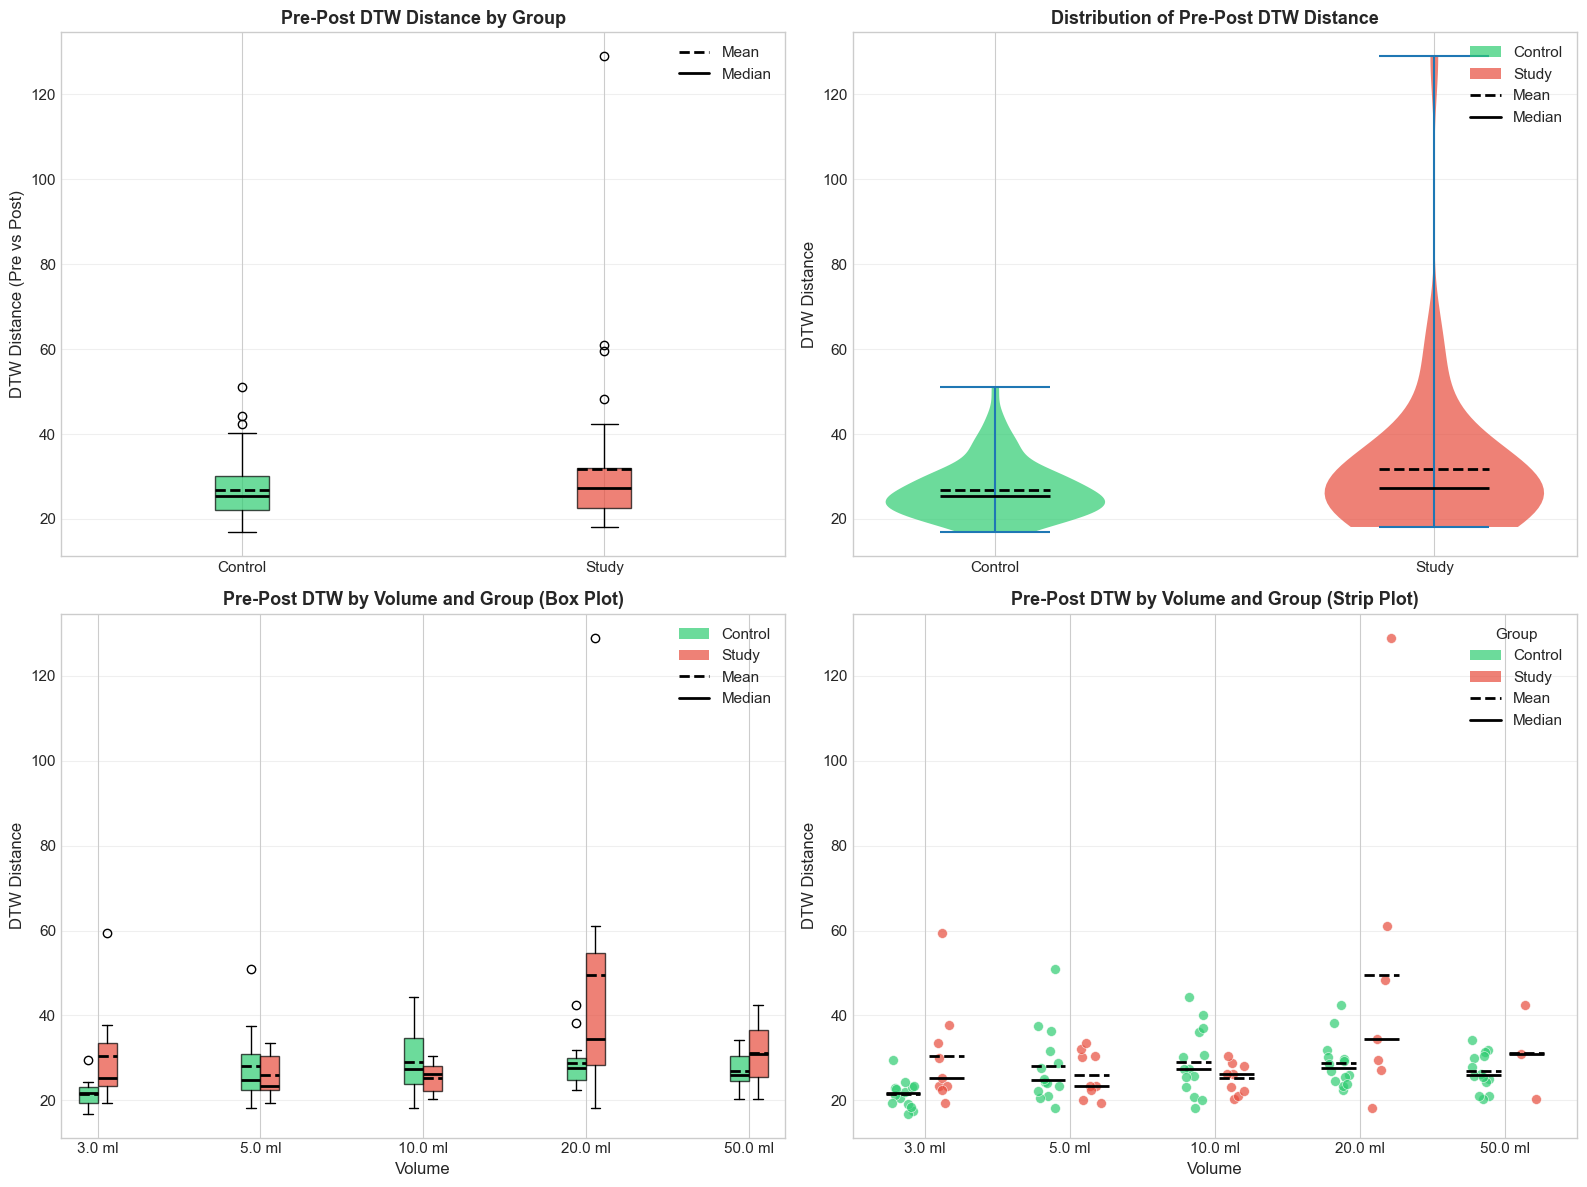


DTW DISTANCE STATISTICS BY GROUP

Control:
  n=70, mean=26.84, std=6.76, median=25.48
  min=16.85, max=51.02
  Q1=22.20, Q3=30.12

Study:
  n=37, mean=31.82, std=19.22, median=27.25
  min=18.10, max=129.01
  Q1=22.46, Q3=32.08

DTW DISTANCE STATISTICS BY VOLUME AND GROUP

--- Volume: 3.0 ml ---
  Control: n=14, mean=21.53, std=3.28, median=21.71
  Study: n=9, mean=30.52, std=12.34, median=25.27

--- Volume: 5.0 ml ---
  Control: n=14, mean=28.00, std=8.76, median=24.77
  Study: n=9, mean=26.09, std=5.46, median=23.41

--- Volume: 10.0 ml ---
  Control: n=14, mean=29.08, std=7.88, median=27.33
  Study: n=9, mean=25.18, std=3.58, median=26.19

--- Volume: 20.0 ml ---
  Control: n=14, mean=28.79, std=5.72, median=27.70
  Study: n=7, mean=49.65, std=37.78, median=34.44

--- Volume: 50.0 ml ---
  Control: n=14, mean=26.81, std=4.36, median=26.00
  Study: n=3, mean=31.17, std=11.08, median=30.82


In [141]:
# COMPLETE VERSION - All 4 plots with MEAN (dashed) and MEDIAN (solid)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

groups = list(alignment_results['group'].unique())
colors = {'Control': '#2ecc71', 'Study': '#e74c3c'}

# Derive volume order from data; sorted() gives ascending numeric order without a hardcoded list.
valid_volumes = sorted(alignment_results['volume_ml'].unique())

# ===========================================
# Plot 1: Box plot by Group (TOP LEFT)
# ===========================================
ax = axes[0, 0]
box_data = [alignment_results[alignment_results['group'] == g]['dtw_distance'].values for g in groups]
bp = ax.boxplot(box_data, labels=groups, patch_artist=True, 
                showmeans=True, meanline=True,
                meanprops=dict(color='black', linewidth=2, linestyle='--'),
                medianprops=dict(color='black', linewidth=2, linestyle='-'))  # Solid line for median

for patch, g in zip(bp['boxes'], groups):
    patch.set_facecolor(colors.get(g, 'gray'))
    patch.set_alpha(0.7)

ax.set_ylabel('DTW Distance (Pre vs Post)', fontsize=12)
ax.set_title('Pre-Post DTW Distance by Group', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Legend
mean_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Mean')
median_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Median')
ax.legend(handles=[mean_line, median_line], loc='upper right')

# ===========================================
# Plot 2: Violin plot by Group (TOP RIGHT)
# ===========================================
ax = axes[0, 1]
parts = ax.violinplot([alignment_results[alignment_results['group'] == g]['dtw_distance'].values for g in groups],
                      positions=range(len(groups)), showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors.get(groups[i], 'gray'))
    pc.set_alpha(0.7)

# Mean = dashed, Median = solid
parts['cmeans'].set_color('black')
parts['cmeans'].set_linewidth(2)
parts['cmeans'].set_linestyle('--')

parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
parts['cmedians'].set_linestyle('-')

ax.set_xticks(range(len(groups)))
ax.set_xticklabels(groups)
ax.set_ylabel('DTW Distance', fontsize=12)
ax.set_title('Distribution of Pre-Post DTW Distance', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Legend
mean_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Mean')
median_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Median')
group_patches = [mpatches.Patch(facecolor=colors.get(g), alpha=0.7, label=g) for g in groups]
ax.legend(handles=group_patches + [mean_line, median_line], loc='upper right')

# ===========================================
# Plot 3: Boxplot by Volume and Group (BOTTOM LEFT)
# ===========================================
ax = axes[1, 0]

positions = []
box_data = []
box_colors = []

width = 0.35
n_groups = len(groups)

for i, vol in enumerate(valid_volumes):
    for j, g in enumerate(groups):
        subset = alignment_results[
            (alignment_results['volume_ml'] == vol) & 
            (alignment_results['group'] == g)
        ]['dtw_distance'].values
        
        if len(subset) > 0:
            box_data.append(subset)
            pos = i * (n_groups + 1) + j * width
            positions.append(pos)
            box_colors.append(colors.get(g, 'gray'))

bp = ax.boxplot(box_data, positions=positions, widths=width, patch_artist=True, 
                showmeans=True, meanline=True,
                meanprops=dict(color='black', linewidth=2, linestyle='--'),
                medianprops=dict(color='black', linewidth=2, linestyle='-'))  # Solid line for median

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

tick_positions = [i * (n_groups + 1) + width * (n_groups - 1) / 2 for i in range(len(valid_volumes))]
ax.set_xticks(tick_positions)
ax.set_xticklabels([f'{v} ml' for v in valid_volumes])

ax.set_xlabel('Volume', fontsize=12)
ax.set_ylabel('DTW Distance', fontsize=12)
ax.set_title('Pre-Post DTW by Volume and Group (Box Plot)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Legend
legend_patches = [mpatches.Patch(facecolor=colors.get(g), alpha=0.7, label=g) for g in groups]
mean_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Mean')
median_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Median')
ax.legend(handles=legend_patches + [mean_line, median_line], loc='upper right')

# ===========================================
# Plot 4: Strip plot by Volume and Group (BOTTOM RIGHT)
# ===========================================
ax = axes[1, 1]

np.random.seed(42)

for i, vol in enumerate(valid_volumes):
    for j, g in enumerate(groups):
        subset = alignment_results[
            (alignment_results['volume_ml'] == vol) & 
            (alignment_results['group'] == g)
        ]['dtw_distance'].values
        
        if len(subset) > 0:
            base_x = i + (j - 0.5) * 0.3
            jitter = np.random.uniform(-0.08, 0.08, len(subset))
            x_values = base_x + jitter
            
            ax.scatter(
                x_values, 
                subset,
                c=colors.get(g, 'gray'),
                alpha=0.7,
                s=50,
                edgecolors='white',
                linewidths=0.5,
                label=g if i == 0 else None
            )
            
            # Add mean line (dashed)
            mean_val = np.mean(subset)
            ax.hlines(mean_val, base_x - 0.12, base_x + 0.12, colors='black', 
                      linewidths=2, linestyles='--')
            
            # Add median line (solid)
            median_val = np.median(subset)
            ax.hlines(median_val, base_x - 0.12, base_x + 0.12, colors='black', 
                      linewidths=2, linestyles='-')

ax.set_xticks(range(len(valid_volumes)))
ax.set_xticklabels([f'{v} ml' for v in valid_volumes])

ax.set_xlabel('Volume', fontsize=12)
ax.set_ylabel('DTW Distance', fontsize=12)
ax.set_title('Pre-Post DTW by Volume and Group (Strip Plot)', fontsize=13, fontweight='bold')

# Legend
legend_patches = [mpatches.Patch(facecolor=colors.get(g), alpha=0.7, label=g) for g in groups]
mean_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Mean')
median_line = plt.Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Median')
ax.legend(handles=legend_patches + [mean_line, median_line], title='Group', loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'pre_post_dtw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


# ===========================================
# Print Statistics
# ===========================================
print("\n" + "="*70)
print("DTW DISTANCE STATISTICS BY GROUP")
print("="*70)

for g in groups:
    subset = alignment_results[alignment_results['group'] == g]['dtw_distance']
    print(f"\n{g}:")
    print(f"  n={len(subset)}, mean={subset.mean():.2f}, std={subset.std():.2f}, median={subset.median():.2f}")
    print(f"  min={subset.min():.2f}, max={subset.max():.2f}")
    print(f"  Q1={subset.quantile(0.25):.2f}, Q3={subset.quantile(0.75):.2f}")

print("\n" + "="*70)
print("DTW DISTANCE STATISTICS BY VOLUME AND GROUP")
print("="*70)

for vol in valid_volumes:
    print(f"\n--- Volume: {vol} ml ---")
    for g in groups:
        subset = alignment_results[
            (alignment_results['volume_ml'] == vol) & 
            (alignment_results['group'] == g)
        ]['dtw_distance']
        
        if len(subset) > 0:
            print(f"  {g}: n={len(subset)}, mean={subset.mean():.2f}, "
                  f"std={subset.std():.2f}, median={subset.median():.2f}")
        else:
            print(f"  {g}: No data")

## 3. Feature Extraction 

In [142]:
def extract_basic_features(aligned_pairs, alignment_results):
    """
    Compute hand-crafted statistical features from aligned pre/post SPL pairs.

    Features include mean, std, max, min, range, skewness, kurtosis, energy,
    RMS, median, IQR (for both pre and post), plus energy ratio, mean ratio,
    pre-post Pearson correlation, and DTW distance.

    Parameters
    ----------
    aligned_pairs : dict[str, dict]
        Output of compute_pre_post_dtw_alignment.
    alignment_results : pd.DataFrame
        Output of compute_pre_post_dtw_alignment (for group/volume metadata).

    Returns
    -------
    pd.DataFrame
        One row per audio file; columns are feature names plus group, volume_ml.
    """
    feature_records = []
    
    for audio_file in aligned_pairs.keys():
        data = aligned_pairs[audio_file]
        meta = alignment_results[alignment_results['audio_file'] == audio_file].iloc[0]
        
        pre = data['pre']
        post = data['post']
                
        features = {'audio_file': audio_file}
        
        # Pre-swallow features
        features['pre_mean'] = np.mean(pre)
        features['pre_std'] = np.std(pre)
        features['pre_max'] = np.max(pre)
        features['pre_min'] = np.min(pre)
        features['pre_range'] = np.ptp(pre)
        features['pre_skew'] = stats.skew(pre)
        features['pre_kurtosis'] = stats.kurtosis(pre)
        features['pre_energy'] = np.sum(pre**2)
        features['pre_rms'] = np.sqrt(np.mean(pre**2))
        features['pre_median'] = np.median(pre)
        features['pre_iqr'] = np.percentile(pre, 75) - np.percentile(pre, 25)
        
        # Post-swallow features
        features['post_mean'] = np.mean(post)
        features['post_std'] = np.std(post)
        features['post_max'] = np.max(post)
        features['post_min'] = np.min(post)
        features['post_range'] = np.ptp(post)
        features['post_skew'] = stats.skew(post)
        features['post_kurtosis'] = stats.kurtosis(post)
        features['post_energy'] = np.sum(post**2)
        features['post_rms'] = np.sqrt(np.mean(post**2))
        features['post_median'] = np.median(post)
        features['post_iqr'] = np.percentile(post, 75) - np.percentile(post, 25)
              
        # Ratios
        features['energy_ratio'] = features['post_energy'] / (features['pre_energy'] + 1e-10)
        features['mean_ratio'] = features['post_mean'] / (features['pre_mean'] + 1e-10)
        features['pre_post_correlation'] = np.corrcoef(pre, post)[0, 1]
        features['dtw_distance'] = data['distance']
        
        # Metadata
        features['group'] = meta['group']
        features['volume_ml'] = meta['volume_ml']
        
        feature_records.append(features)
    
    return pd.DataFrame(feature_records)

basic_features_df = extract_basic_features(aligned_pairs, alignment_results)
print(f"Basic features shape: {basic_features_df.shape}")

Basic features shape: (107, 29)


In [143]:
# Prepare tsfresh data
def prepare_tsfresh_data(aligned_pairs):
    """
    Reshape aligned pre/post signals into the long format required by tsfresh.

    tsfresh expects: id (audio_file), time (frequency bin index), and one
    column per signal (pre_spl, post_spl). This function creates that structure.

    Parameters
    ----------
    aligned_pairs : dict[str, dict]
        Output of compute_pre_post_dtw_alignment.

    Returns
    -------
    pd.DataFrame
        Long-format table with columns: id, time, pre_spl, post_spl.
        Each audio file contributes N rows (one per frequency bin).
    """
    records = []
    for audio_file, data in aligned_pairs.items():
        pre = data['pre']
        post = data['post']
               
        for t in range(len(pre)):
            records.append({
                'id': audio_file,
                'time': t,
                'pre_spl': pre[t],
                'post_spl': post[t],
            })
    return pd.DataFrame(records)

tsfresh_data = prepare_tsfresh_data(aligned_pairs)
print(f"tsfresh data shape: {tsfresh_data.shape}")

tsfresh data shape: (19688, 4)


In [144]:
# Extract COMPREHENSIVE features from PRE-SWALLOW
print("="*60)
print("Extracting COMPREHENSIVE features from PRE-SWALLOW signal...")
print("This will take several minutes...")
print("="*60)

pre_features = extract_features(
    tsfresh_data[['id', 'time', 'pre_spl']],
    column_id='id', column_sort='time', column_value='pre_spl',
    default_fc_parameters=ComprehensiveFCParameters(),
    n_jobs=0, disable_progressbar=False
)

impute(pre_features)
zero_var = pre_features.var() == 0
pre_features_clean = pre_features.loc[:, ~zero_var]
# Guard against double-prefixing: tsfresh already uses the input column name
# as part of the feature name (e.g. 'pre_spl__mean'), so we only add 'pre_'
# to columns that do not already start with it.
pre_features_clean.columns = [
    c if c.startswith('pre_') else 'pre_' + c
    for c in pre_features_clean.columns
]

print(f"\nPre-swallow features: {pre_features_clean.shape[1]}")

Extracting COMPREHENSIVE features from PRE-SWALLOW signal...
This will take several minutes...


Feature Extraction: 100%|██████████| 107/107 [00:14<00:00,  7.34it/s]



Pre-swallow features: 696


In [145]:
# Extract COMPREHENSIVE features from POST-SWALLOW
print("="*60)
print("Extracting COMPREHENSIVE features from POST-SWALLOW signal...")
print("="*60)

post_features = extract_features(
    tsfresh_data[['id', 'time', 'post_spl']],
    column_id='id', column_sort='time', column_value='post_spl',
    default_fc_parameters=ComprehensiveFCParameters(),
    n_jobs=0, disable_progressbar=False
)

impute(post_features)
zero_var = post_features.var() == 0
post_features_clean = post_features.loc[:, ~zero_var]
# Same guard as PRE cell: avoid creating 'post_post_spl__*' double-prefix.
post_features_clean.columns = [
    c if c.startswith('post_') else 'post_' + c
    for c in post_features_clean.columns
]

print(f"\nPost-swallow features: {post_features_clean.shape[1]}")

Extracting COMPREHENSIVE features from POST-SWALLOW signal...


Feature Extraction: 100%|██████████| 107/107 [00:13<00:00,  7.99it/s]



Post-swallow features: 697


In [146]:
# Combine all features
print("\n" + "="*60)
print("COMBINING ALL FEATURES")
print("="*60)

all_tsfresh = pd.concat([pre_features_clean, post_features_clean], axis=1)
all_tsfresh['audio_file'] = all_tsfresh.index

final_features_df = basic_features_df.merge(all_tsfresh, on='audio_file', how='inner')

metadata_cols = ['audio_file', 'group', 'volume_ml']
feature_cols = [c for c in final_features_df.columns if c not in metadata_cols]

print(f"\nFinal features shape: {final_features_df.shape}")
print(f"\nFeature breakdown:")
print(f"  - Basic: {basic_features_df.shape[1] - 3}")
print(f"  - Pre tsfresh: {pre_features_clean.shape[1]}")
print(f"  - Post tsfresh: {post_features_clean.shape[1]}")
print(f"  - TOTAL: {len(feature_cols)}")

# Path defined in CONFIG cell — see top of notebook
final_features_df.to_csv(FEATURES_COMPREHENSIVE_PATH, index=False)
print(f"\nSaved to: {FEATURES_COMPREHENSIVE_PATH}")


COMBINING ALL FEATURES

Final features shape: (107, 1422)

Feature breakdown:
  - Basic: 26
  - Pre tsfresh: 696
  - Post tsfresh: 697
  - TOTAL: 1419

Saved to: C:\Users\Teresa\Documents\GitHub\Swallowing-Detection-with-Machine-Learning\Audio_analysis\extracted_features_comprehensive.csv


## 4. Two way mixed ANOVA 

### 4.1. Check data 

In [147]:
# Load the extracted features
# Path defined in CONFIG cell — see top of notebook
# This file is produced by the feature-extraction cells (Section 3).
# If it does not exist, run Sections 1-3 first.
df_features = pd.read_csv(FEATURES_COMPREHENSIVE_PATH)

print(f"Data shape: {df_features.shape}")
print(f"Groups: {df_features['group'].unique()}")

# Volume extraction was already applied in Section 1.1 before feature
# extraction, so volumes should be correct. Re-apply as safety net.
df_features['volume_ml'] = df_features['audio_file'].apply(extract_volume)
n_nan = df_features['volume_ml'].isna().sum()
if n_nan > 0:
    print(f"\n⚠ {n_nan} rows still have NaN volume:")
    print(df_features[df_features['volume_ml'].isna()]['audio_file'].tolist())
else:
    print("✓ All volumes present")

print(f"\nVolumes: {sorted(df_features['volume_ml'].unique())}")
print(f"Samples per volume:\n{df_features['volume_ml'].value_counts().sort_index()}")

# Quick check: do tsfresh columns exist?
tsfresh_cols = [c for c in df_features.columns if 'spl__' in c]
print(f"\ntsfresh columns found: {len(tsfresh_cols)}")
if len(tsfresh_cols) == 0:
    print("⚠ WARNING: No tsfresh columns found! Did you re-run Sections 1-3 after the refactor?")
    print("  Columns present:", [c for c in df_features.columns if c not in ['audio_file','group','volume_ml']][:20])
elif tsfresh_cols[0].startswith('pre_pre_') or tsfresh_cols[0].startswith('post_post_'):
    print("⚠ WARNING: Old double-prefix column names detected (pre_pre_spl__*).")
    print("  Re-run Sections 1-3 to regenerate with correct names.")

Data shape: (107, 1422)
Groups: ['Control' 'Study']
✓ All volumes present

Volumes: [3.0, 5.0, 10.0, 20.0, 50.0]
Samples per volume:
volume_ml
3.0     23
5.0     23
10.0    23
20.0    21
50.0    17
Name: count, dtype: int64

tsfresh columns found: 1393


### 4.2. Convert to spss format for other analysis

In [148]:
# Get all column names
all_cols = df_features.columns.tolist()
meta_cols = ['audio_file', 'group', 'volume_ml']

# Unpaired features that combine pre+post info — these go through as-is
UNPAIRED_FEATURES = ['energy_ratio', 'mean_ratio', 'pre_post_correlation', 'dtw_distance']
unpaired_present = [c for c in UNPAIRED_FEATURES if c in all_cols]
print(f"Unpaired features (carried through directly): {unpaired_present}")

def find_feature_pairs(columns):
    """
    Identify matching pre/post column pairs for reshaping to long format.

    Handles two column naming conventions:
      - Basic features:   pre_<n>   <->  post_<n>
      - tsfresh features: pre_spl__<n>  <->  post_spl__<n>

    Also auto-detects the old double-prefix naming (pre_pre_spl__<n>) and
    falls back to matching those if the new names aren't found.

    Parameters
    ----------
    columns : list[str]
        All column names in the wide-format features DataFrame.

    Returns
    -------
    list[dict]
        Each dict has keys: 'feature_name', 'pre_col', 'post_col'.
    """
    pairs = []

    # Basic features (pre_X and post_X), excluding unpaired and tsfresh
    skip_prefixes = ('pre_spl__', 'pre_pre_spl__')
    basic_pre = [c for c in columns
                 if c.startswith('pre_') and not any(c.startswith(p) for p in skip_prefixes)
                 and c not in UNPAIRED_FEATURES]
    for pre_col in basic_pre:
        feature_name = pre_col[4:]  # Remove 'pre_'
        post_col = f'post_{feature_name}'
        if post_col in columns:
            pairs.append({
                'feature_name': feature_name,
                'pre_col': pre_col,
                'post_col': post_col
            })

    # tsfresh features — try new naming first, fall back to old double-prefix
    tsfresh_pre_new = [c for c in columns if c.startswith('pre_spl__')]
    tsfresh_pre_old = [c for c in columns if c.startswith('pre_pre_spl__')]

    if tsfresh_pre_new:
        # New naming: pre_spl__X <-> post_spl__X
        for pre_col in tsfresh_pre_new:
            feature_name = pre_col[9:]   # Remove 'pre_spl__' (9 chars)
            post_col = f'post_spl__{feature_name}'
            if post_col in columns:
                pairs.append({
                    'feature_name': f'tsfresh_{feature_name}',
                    'pre_col': pre_col,
                    'post_col': post_col
                })
    elif tsfresh_pre_old:
        # Old naming: pre_pre_spl__X <-> post_post_spl__X
        print("⚠ Detected OLD double-prefix column names (pre_pre_spl__*).")
        print("  Matching them anyway, but re-running Sections 1-3 is recommended.")
        for pre_col in tsfresh_pre_old:
            feature_name = pre_col[13:]  # Remove 'pre_pre_spl__' (13 chars)
            post_col = f'post_post_spl__{feature_name}'
            if post_col in columns:
                pairs.append({
                    'feature_name': f'tsfresh_{feature_name}',
                    'pre_col': pre_col,
                    'post_col': post_col
                })

    return pairs

feature_pairs = find_feature_pairs(all_cols)

# Count breakdown
n_basic = len([p for p in feature_pairs if not p['feature_name'].startswith('tsfresh_')])
n_tsfresh = len([p for p in feature_pairs if p['feature_name'].startswith('tsfresh_')])
print(f"\nFound {len(feature_pairs)} matching pre/post feature pairs:")
print(f"  Basic pairs: {n_basic}")
print(f"  tsfresh pairs: {n_tsfresh}")

if n_tsfresh == 0:
    raise ValueError(
        "Zero tsfresh feature pairs found! The CSV likely has old column names. "
        "Re-run Sections 1-3 to regenerate extracted_features_comprehensive.csv."
    )

print(f"\nFirst 10 pairs:")
for p in feature_pairs[:10]:
    print(f"  {p['feature_name']}: {p['pre_col']} <-> {p['post_col']}")

Unpaired features (carried through directly): ['energy_ratio', 'mean_ratio', 'pre_post_correlation', 'dtw_distance']

Found 706 matching pre/post feature pairs:
  Basic pairs: 11
  tsfresh pairs: 695

First 10 pairs:
  mean: pre_mean <-> post_mean
  std: pre_std <-> post_std
  max: pre_max <-> post_max
  min: pre_min <-> post_min
  range: pre_range <-> post_range
  skew: pre_skew <-> post_skew
  kurtosis: pre_kurtosis <-> post_kurtosis
  energy: pre_energy <-> post_energy
  rms: pre_rms <-> post_rms
  median: pre_median <-> post_median


In [149]:
def reshape_to_long(df_wide, feature_pairs, unpaired_cols):
    """
    Reshape wide-format features to long format for mixed repeated-measures ANOVA.

    Each original row (one subject x one volume) becomes two rows: one for the
    Pre condition and one for the Post condition. Feature values are taken from
    the corresponding pre_col / post_col as identified by find_feature_pairs.

    Unpaired features (e.g. energy_ratio, dtw_distance) that already combine
    pre+post information are copied identically into both rows so they remain
    available for downstream analysis.

    Parameters
    ----------
    df_wide : pd.DataFrame
        Wide-format feature table.
    feature_pairs : list[dict]
        Output of find_feature_pairs.
    unpaired_cols : list[str]
        Column names for features that don't have pre/post variants.

    Returns
    -------
    pd.DataFrame
        Long-format table with columns: subject, condition ('Pre'/'Post'),
        group, volume_ml, one column per feature_name, and unpaired columns.
    """
    long_records = []

    for idx, row in df_wide.iterrows():
        base = {
            'subject': row['audio_file'],
            'group': row['group'],
            'volume_ml': row['volume_ml'],
        }
        # Copy unpaired features into both conditions
        for col in unpaired_cols:
            base[col] = row[col]

        # Pre condition
        pre_record = {**base, 'condition': 'Pre'}
        for pair in feature_pairs:
            pre_record[pair['feature_name']] = row[pair['pre_col']]
        long_records.append(pre_record)

        # Post condition
        post_record = {**base, 'condition': 'Post'}
        for pair in feature_pairs:
            post_record[pair['feature_name']] = row[pair['post_col']]
        long_records.append(post_record)

    return pd.DataFrame(long_records)

# Reshape data
long_df = reshape_to_long(df_features, feature_pairs, unpaired_present)
print(f"Long format shape: {long_df.shape}")
print(f"Rows per subject: {long_df.groupby('subject').size().unique()}")
print(f"\nSample of long format:")
print(long_df.head(4))
# Path defined in CONFIG cell — see top of notebook
long_df.to_csv(FEATURES_ANOVA_PATH, index=False)
print(f"\nSaved to: {FEATURES_ANOVA_PATH}")

Long format shape: (214, 714)
Rows per subject: [2]

Sample of long format:
           subject    group  volume_ml  energy_ratio  mean_ratio  \
0  GC-F10-10ml.wav  Control       10.0      0.956996    0.852294   
1  GC-F10-10ml.wav  Control       10.0      0.956996    0.852294   
2  GC-F10-20ml.wav  Control       20.0      0.865997    0.709761   
3  GC-F10-20ml.wav  Control       20.0      0.865997    0.709761   

   pre_post_correlation  dtw_distance condition       mean        std  ...  \
0              0.969086     27.321246       Pre -11.025078  22.135104  ...   
1              0.969086     27.321246      Post  -9.396603  22.291735  ...   
2              0.919232     25.996404       Pre -19.286976  20.156325  ...   
3              0.919232     25.996404      Post -13.689143  22.058615  ...   

   tsfresh_fourier_entropy__bins_3  tsfresh_fourier_entropy__bins_5  \
0                         0.059432                         0.059432   
1                         0.059432                

### 4.3. Remove 50mL data due to low number of study group subjects

In [150]:
# Path defined in CONFIG cell — see top of notebook
# This file is produced by Section 4.2. Run that cell first if missing.
df_long = pd.read_csv(FEATURES_ANOVA_PATH)
print(f'Original dataset: {df_long.shape[0]} rows × {df_long.shape[1]} columns')

# Extract base_subject (subject identity across volumes)
df_long['base_subject'] = df_long['subject'].str.extract(r'(G[CE][-_][A-Z]\d+)')
df_long['base_subject'] = df_long['base_subject'].str.replace('_', '-')

# Remove 50ml (insufficient sample in Study group)
df_long = df_long[df_long['volume_ml'] != 50.0].copy()
print(f'After removing 50ml: {df_long.shape[0]} rows')

# Verify structure
print(f'\nSubjects per group:')
for g in sorted(df_long['group'].unique()):
    n = df_long[df_long['group'] == g]['base_subject'].nunique()
    print(f'  {g}: {n} subjects')

print(f'\nGroup × Condition × Volume counts:')
counts = df_long.groupby(['group', 'condition', 'volume_ml']).size().unstack(fill_value=0)
display(counts)

# Define feature columns (exclude metadata)
meta_cols = ['subject', 'condition', 'group', 'volume_ml', 'base_subject']
feature_cols = [c for c in df_long.columns if c not in meta_cols]
print(f'\nTotal initial features: {len(feature_cols)}')

Original dataset: 214 rows × 714 columns
After removing 50ml: 180 rows

Subjects per group:
  Control: 14 subjects
  Study: 9 subjects

Group × Condition × Volume counts:


volume_ml          3.0   5.0   10.0  20.0
group   condition                        
Control Post         14    14    14    14
        Pre          14    14    14    14
Study   Post          9     9     9     7
        Pre           9     9     9     7


Total initial features: 710


### 4.4. Removal of Constant / Near-Constant Features

Features where >95% of values are identical are removed. These produce unstable F-ratios, violate normality assumptions, and have no clinical discriminative value.

In [151]:
CONST_THRESHOLD = 0.95  # Remove if >95% of values are identical

features_to_remove = []
removal_reasons = []

for col in feature_cols:
    series = df_long[col]

    # Zero variance — use tolerance to avoid false negatives from floating-point rounding
    if series.std() < 1e-10:
        features_to_remove.append(col)
        removal_reasons.append('zero variance')
        continue

    # Near-constant: most frequent value appears in >95% of rows
    most_common_pct = series.value_counts(normalize=True).iloc[0]
    if most_common_pct > CONST_THRESHOLD:
        features_to_remove.append(col)
        removal_reasons.append(f'dominant value in {most_common_pct:.1%} of cases')
        continue

print(f'Features removed ({len(features_to_remove)}):')
removed_df = pd.DataFrame({'feature': features_to_remove, 'reason': removal_reasons})
display(removed_df)

# Apply removal
feature_cols = [c for c in feature_cols if c not in features_to_remove]
print(f'\nRemaining features for analysis: {len(feature_cols)}')

Features removed (6):


,feature,reason
0,tsfresh_first_location_of_minimum,zero variance
1,tsfresh_autocorrelation__lag_0,zero variance
2,"tsfresh_fft_coefficient__attr_""angle""__coeff_0",dominant value in 97.8% of cases
3,"tsfresh_linear_trend__attr_""pvalue""",zero variance
4,tsfresh_fourier_entropy__bins_2,zero variance
5,tsfresh_fourier_entropy__bins_3,dominant value in 95.6% of cases



Remaining features for analysis: 704


## 5. Statistic analysis

### 5.1. Normalcy test (Shapiro-Wilk) and homogeneity test (Levene)

In [152]:
volumes = sorted(df_long['volume_ml'].unique())
groups = sorted(df_long['group'].unique())
conditions = sorted(df_long['condition'].unique())
assumption_results = []

non_normal_features = {}  
normal_features = {}      

for vol in volumes:
    df_vol = df_long[df_long['volume_ml'] == vol]
    norm_fail = 0
    lev_fail = 0
    total_norm = 0
    total_lev = 0
    failed_feats = set()
    tested_feats = set()

    for feat in feature_cols:
        if df_vol[feat].std() < 1e-10:  # use tolerance, not exact equality
            continue

        feat_failed = False
        for g in groups:
            for cond in conditions:
                data = df_vol[(df_vol['group'] == g) & (df_vol['condition'] == cond)][feat].dropna()
                if len(data) >= 3:
                    stat, p = stats.shapiro(data)
                    total_norm += 1
                    tested_feats.add(feat)
                    if p < 0.05:
                        norm_fail += 1
                        feat_failed = True

        if feat_failed:
            failed_feats.add(feat)

        for cond in conditions:
            groups_data = [
                df_vol[(df_vol['group'] == g) & (df_vol['condition'] == cond)][feat].dropna().values
                for g in groups
            ]
            if all(len(d) >= 2 for d in groups_data):
                stat, p = stats.levene(*groups_data)
                total_lev += 1
                if p < 0.05:
                    lev_fail += 1

    non_normal_features[vol] = failed_feats
    normal_features[vol] = tested_feats - failed_feats

    assumption_results.append({
        'Volume (ml)': int(vol),
        'Features tested': len(tested_feats),
        'Normality violations': f'{norm_fail}/{total_norm} ({norm_fail/total_norm:.1%})',
        'Homogeneity violations': f'{lev_fail}/{total_lev} ({lev_fail/total_lev:.1%})',
    })

display(pd.DataFrame(assumption_results).set_index('Volume (ml)'))

# --- KEY OUTPUT ---
# Features that passed normality in ALL volumes → use for repeated measures ANOVA
parametric_features = sorted(set.intersection(*normal_features.values()))

# Features that failed normality in ANY volume → use for non-parametric tests
nonparametric_features = sorted(set.union(*non_normal_features.values()))

print(f"\n✓ Parametric features (passed Shapiro-Wilk in all volumes): {len(parametric_features)}")
print(f"  {parametric_features}")
print(f"\n✗ Non-parametric features (failed in at least one volume): {len(nonparametric_features)}")
print(f"  {nonparametric_features}")

c:\Users\Teresa\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Teresa\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:3104: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom


,Features tested,Normality violations,Homogeneity violations
Volume (ml),,,
3,704,321/2816 (11.4%),66/1408 (4.7%)
5,704,314/2816 (11.2%),42/1408 (3.0%)
10,704,360/2816 (12.8%),49/1408 (3.5%)
20,704,368/2816 (13.1%),71/1408 (5.0%)



✓ Parametric features (passed Shapiro-Wilk in all volumes): 182
  ['energy_ratio', 'mean', 'rms', 'tsfresh_agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"min"', 'tsfresh_agg_linear_trend__attr_"stderr"__chunk_len_5__f_agg_"max"', 'tsfresh_approximate_entropy__m_2__r_0.1', 'tsfresh_ar_coefficient__coeff_7__k_10', 'tsfresh_ar_coefficient__coeff_8__k_10', 'tsfresh_c3__lag_1', 'tsfresh_c3__lag_2', 'tsfresh_c3__lag_3', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_0.2__ql_0.0', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_0.6__ql_0.2', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.6', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.8', 'tsfresh_cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'tsfresh_cwt

#### Failed normalcy test

In [153]:
# Build a detailed table of normality failures per feature × volume
failure_rows = []

for vol in volumes:
    for feat in sorted(non_normal_features[vol]):
        # Collect which cells failed
        failed_cells = []
        for g in groups:
            for cond in conditions:
                df_vol = df_long[df_long['volume_ml'] == vol]
                data = df_vol[(df_vol['group'] == g) & (df_vol['condition'] == cond)][feat].dropna()
                if len(data) >= 3:
                    stat, p = stats.shapiro(data)
                    if p < 0.05:
                        failed_cells.append(f"{g}×{cond} (p={p:.4f})")

        failure_rows.append({
            'Feature': feat,
            'Volume (ml)': int(vol),
            'Failed cells': '; '.join(failed_cells),
            'N failures': len(failed_cells),
        })

df_failures = pd.DataFrame(failure_rows).sort_values(['Feature', 'Volume (ml)'])

display_table(df_failures, "Normality Failures per Feature x Volume")

print(f"\nTotal entries: {len(df_failures)} (feature × volume combinations that failed normality)")

c:\Users\Teresa\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


Feature,Volume (ml),Failed cells,N failures
dtw_distance,3,Study×Post (p=0.0217); Study×Pre (p=0.0217),2
dtw_distance,5,Control×Post (p=0.0295); Control×Pre (p=0.0295),2
dtw_distance,20,Study×Post (p=0.0289); Study×Pre (p=0.0289),2
energy,3,Control×Post (p=0.0315); Control×Pre (p=0.0401),2
iqr,5,Control×Post (p=0.0065),1
iqr,10,Study×Pre (p=0.0082),1
kurtosis,3,Control×Post (p=0.0301),1
kurtosis,5,Control×Post (p=0.0136),1
kurtosis,10,Study×Pre (p=0.0009),1
kurtosis,20,Control×Post (p=0.0384),1



Total entries: 946 (feature × volume combinations that failed normality)


### 5.2. Two way mixed ANOVA of variables with normal distribution

For each volume, a two way ANOVA is run on every feature with:
- **Between-subjects factor:** Group (Control vs Study)  
- **Within-subjects factor:** Condition (Pre vs Post)  

This yields 3 effects per feature per volume:
1. **Group** — main effect of group
2. **Condition** — main effect of phase (pre vs post)
3. **Interaction** — Group × Phase interaction (clinically most relevant)

In [154]:
# pingouin imported in the imports cell
anova_results = []
_anova_errors = 0  # counts exceptions so they are not silently lost

for vol in volumes:
    df_vol = df_long[df_long['volume_ml'] == vol].copy()

    for feat in parametric_features:
        try:
            aov = pg.mixed_anova(
                data=df_vol,
                dv=feat,
                within='condition',
                between='group',
                subject='subject',  
            )

            # --- Pre-compute group means for Mean Diff column ---
            cond_means = df_vol.groupby('condition')[feat].mean()
            group_means = df_vol.groupby('group')[feat].mean()
            cell_means = df_vol.groupby(['condition', 'group'])[feat].mean()

            for _, row in aov.iterrows():
                source = row['Source']

                # Compute mean diff matching Tukey logic
                if source == 'condition' and len(cond_means) == 2:
                    levels = sorted(cond_means.index)
                    mean_diff = round(cond_means[levels[0]] - cond_means[levels[1]], 4)
                    diff_label = f"{levels[0]} − {levels[1]}"
                elif source == 'group' and len(group_means) == 2:
                    levels = sorted(group_means.index)
                    mean_diff = round(group_means[levels[0]] - group_means[levels[1]], 4)
                    diff_label = f"{levels[0]} − {levels[1]}"
                elif 'nteraction' in source or '*' in source:
                    # Interaction: difference of condition effects across groups
                    grps = sorted(group_means.index)
                    conds = sorted(cond_means.index)
                    if len(grps) == 2 and len(conds) == 2:
                        eff_g0 = cell_means.loc[(conds[0], grps[0])] - cell_means.loc[(conds[1], grps[0])]
                        eff_g1 = cell_means.loc[(conds[0], grps[1])] - cell_means.loc[(conds[1], grps[1])]
                        mean_diff = round(eff_g0 - eff_g1, 4)
                        diff_label = f"Δ({conds[0]}−{conds[1]}): {grps[0]} − {grps[1]}"
                    else:
                        mean_diff = None
                        diff_label = ''
                else:
                    mean_diff = None
                    diff_label = ''

                anova_results.append({
                    'Volume (ml)': int(vol),
                    'Feature': feat,
                    'Source': source,
                    'F': round(row['F'], 4),
                    'p-value': round(row['p-unc'], 4),
                    'np2': round(row['np2'], 4),  # partial eta-squared
                    'Mean Diff': mean_diff,
                    'Comparison': diff_label,
                    'Significant': '✓' if row['p-unc'] < 0.05 else '',
                })
        except Exception as e:
            _anova_errors += 1
            anova_results.append({
                'Volume (ml)': int(vol),
                'Feature': feat,
                'Source': 'ERROR',
                'F': None,
                'p-value': None,
                'np2': None,
                'Mean Diff': None,
                'Comparison': '',
                'Significant': str(e),
            })

df_anova = pd.DataFrame(anova_results)

if _anova_errors > 0:
    import warnings as _w
    _w.warn(
        f"{_anova_errors} feature(s) raised exceptions during mixed ANOVA. "
        "Check rows where Source == 'ERROR' in df_anova.",
        UserWarning, stacklevel=2
    )

# Filter and display only significant results
df_sig = df_anova[df_anova['Significant'] == '✓'].copy()
display_table(df_sig, "Significant ANOVA Effects")

sig_features = sorted(df_sig['Feature'].unique())
print(f"\n{len(df_sig)} significant effects across {len(sig_features)} features "
      f"(out of {len(df_anova)} tests)")
print(sig_features)
# Columns: Volume (ml), Feature, Source, F, p-value, np2, Significant
# Diagnostic: confirm the pingouin RuntimeWarnings did not affect reported results
bad = df_anova[~np.isfinite(df_anova[['F', 'np2']]).all(axis=1)]
print(f"Non-finite F or np2: {len(bad)} of {len(df_anova)} tests")
print(f"  of which significant (p < 0.05): {(bad['p-value'] < 0.05).sum()}")
print(f"Rows with Source == 'ERROR': {(df_anova['Source'] == 'ERROR').sum()}")
print(f"np2 >= 0.999 (degenerate): {(df_anova['np2'] >= 0.999).sum()}")

if len(bad):
    print("\nAffected features by source:")
    print(bad.groupby(['Source'])['Feature'].nunique().to_string())

c:\Users\Teresa\anaconda3\Lib\site-packages\pingouin\parametric.py:571: RuntimeWarning: invalid value encountered in scalar divide
  fval = ms_with / ms_reswith
c:\Users\Teresa\anaconda3\Lib\site-packages\pingouin\parametric.py:1569: RuntimeWarning: divide by zero encountered in scalar divide
  ef_inter = ss_inter / (ss_inter + ss_reswith)


Volume (ml),Feature,Source,F,p-value,np2,Mean Diff,Comparison,Significant
3,tsfresh_approximate_entropy__m_2__r_0.1,Interaction,5.4594,0.0295,0.2063,0.1027,Δ(Post−Pre): Control − Study,✓
3,"tsfresh_change_quantiles__f_agg_""mean""__isabs_False__qh_1.0__ql_0.2",condition,5.9656,0.0235,0.2212,0.0248,Post − Pre,✓
3,"tsfresh_change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",Interaction,5.8410,0.0248,0.2176,0.4136,Δ(Post−Pre): Control − Study,✓
3,"tsfresh_cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)",group,4.9061,0.0380,0.1894,-9.4012,Control − Study,✓
3,"tsfresh_cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)",condition,11.9869,0.0023,0.3634,-1.3922,Post − Pre,✓
3,"tsfresh_cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)",Interaction,4.7278,0.0413,0.1838,4.2299,Δ(Post−Pre): Control − Study,✓
3,"tsfresh_cwt_coefficients__coeff_10__w_5__widths_(2, 5, 10, 20)",group,7.8181,0.0108,0.2713,-7.2855,Control − Study,✓
3,"tsfresh_cwt_coefficients__coeff_14__w_2__widths_(2, 5, 10, 20)",group,6.0205,0.0230,0.2228,-1.0496,Control − Study,✓
3,"tsfresh_cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)",group,5.6997,0.0264,0.2135,-10.4905,Control − Study,✓
3,"tsfresh_cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)",condition,11.2951,0.0030,0.3497,-2.3186,Post − Pre,✓



167 significant effects across 105 features (out of 2184 tests)
['energy_ratio', 'mean', 'rms', 'tsfresh_agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"mean"', 'tsfresh_agg_linear_trend__attr_"stderr"__chunk_len_50__f_agg_"min"', 'tsfresh_approximate_entropy__m_2__r_0.1', 'tsfresh_c3__lag_1', 'tsfresh_c3__lag_2', 'tsfresh_c3__lag_3', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_0.2__ql_0.0', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.2', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_False__qh_1.0__ql_0.4', 'tsfresh_change_quantiles__f_agg_"mean"__isabs_True__qh_1.0__ql_0.8', 'tsfresh_cwt_coefficients__coeff_0__w_10__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_0__w_2__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_10__w_20__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_10__w_5__widths_(2, 5, 10, 20)', 'tsfresh_cwt_coefficients__coeff_12__w_2__wi

In [155]:
print(df_anova[(~np.isfinite(df_anova['F'])) | (df_anova['np2'] >= 0.999)][
    ['Volume (ml)', 'Feature', 'Source', 'F', 'p-value', 'np2', 'Significant']].to_string())

      Volume (ml)       Feature       Source     F  p-value  np2 Significant
1640           20  energy_ratio  Interaction -19.0      1.0  inf            


In [156]:
chk = df_long[df_long['volume_ml'] == 10][['subject', 'group', 'condition', 'energy_ratio']]
print(chk.groupby(['group', 'condition'])['energy_ratio'].agg(['count', 'nunique', 'mean', 'std']).to_string())
print("\nDistinct values overall:", chk['energy_ratio'].nunique())
print(chk['energy_ratio'].value_counts().head(10).to_string())

                   count  nunique      mean       std
group   condition                                    
Control Post          14       14  0.978334  0.051526
        Pre           14       14  0.978334  0.051526
Study   Post           9        9  1.007278  0.097670
        Pre            9        9  1.007278  0.097670

Distinct values overall: 23
energy_ratio
0.956996    2
0.936710    2
0.909763    2
1.151055    2
0.958789    2
0.872169    2
1.056642    2
1.108262    2
1.083428    2
1.002198    2


In [157]:
# Exclude energy_ratio: identical Pre/Post values per subject produce zero
# within-subjects residual variance, so its Condition and Interaction terms
# are mathematically degenerate (F = 21.0 / np2 = 0.5 at 10 mL; F = -19.0 /
# np2 = inf at 20 mL). Not a valid within-subjects feature.
n_before = len(df_anova)
df_anova = df_anova[df_anova['Feature'] != 'energy_ratio'].copy()
df_sig = df_anova[df_anova['Significant'] == '✓'].copy()
print(f"Dropped energy_ratio: {n_before} -> {len(df_anova)} tests, "
      f"{len(df_sig)} significant")

Dropped energy_ratio: 2184 -> 2172 tests, 166 significant


In [158]:
dup = []
for f in parametric_features:
    for vol in volumes:
        d = (df_long[df_long['volume_ml'] == vol]
             .pivot_table(index='subject', columns='condition', values=f))
        if d.shape[1] == 2 and np.allclose(d.iloc[:, 0], d.iloc[:, 1], equal_nan=True):
            dup.append((f, vol))
            break

print(f"{len(dup)} features identical across Pre/Post:")
for f, v in dup:
    print(f"  {f}  (first seen at {v} mL)")

1 features identical across Pre/Post:
  energy_ratio  (first seen at 3.0 mL)


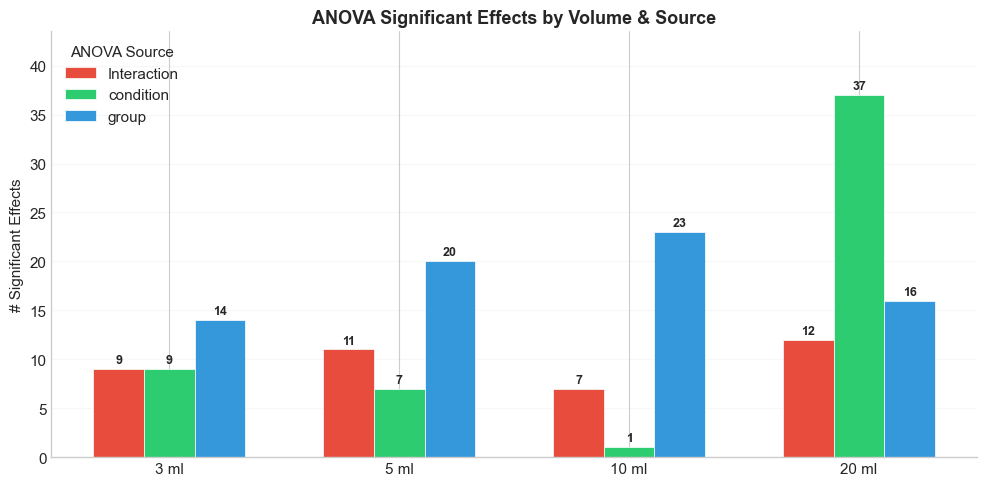


Total significant ANOVA effects: 166
  Interaction: 39
  condition: 54
  group: 73


In [159]:
# ══════════════════════════════════════════════════════════════════════
# ANOVA — Significant Effects by Volume & Source (bar chart)
# ══════════════════════════════════════════════════════════════════════

df_sig_plot = df_anova[df_anova['Significant'] == '✓'].copy()

# Count significant effects per Volume × Source
count_df = (df_sig_plot
            .groupby(['Volume (ml)', 'Source'])
            .size()
            .reset_index(name='Count'))

volumes_plot = sorted(count_df['Volume (ml)'].unique())
sources_plot = sorted(count_df['Source'].unique())

SOURCE_COLORS = {
    'Interaction': '#e74c3c',
    'condition':   '#2ecc71',
    'group':       '#3498db',
}

x = np.arange(len(volumes_plot))
n_sources = len(sources_plot)
bar_width = 0.22

fig, ax = plt.subplots(figsize=(10, 5))

for i, src in enumerate(sources_plot):
    counts = []
    for vol in volumes_plot:
        val = count_df[(count_df['Volume (ml)'] == vol) & (count_df['Source'] == src)]['Count']
        counts.append(val.values[0] if len(val) > 0 else 0)

    offset = (i - (n_sources - 1) / 2) * bar_width
    bars = ax.bar(x + offset, counts, bar_width,
                  label=src, color=SOURCE_COLORS.get(src, '#999999'),
                  edgecolor='white', linewidth=0.5)

    for bar, c in zip(bars, counts):
        if c > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    str(c), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{int(v)} ml' for v in volumes_plot], fontsize=11)
ax.set_ylabel('# Significant Effects', fontsize=11)
ax.set_title('ANOVA Significant Effects by Volume & Source', fontsize=13, fontweight='bold')
ax.legend(title='ANOVA Source', loc='upper left', framealpha=0.9)
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)
ax.grid(axis='y', alpha=0.15)
sns.despine()

plt.tight_layout()
plt.savefig(NOTEBOOK_DIR / 'anova_sig_by_volume_source.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal significant ANOVA effects: {len(df_sig_plot)}")
for src in sources_plot:
    n = len(df_sig_plot[df_sig_plot['Source'] == src])
    print(f"  {src}: {n}")

### 5.3. Post-hoc Tukey

Apenas utiliza as interações na analise retirando a redundacia da 'condition' e 'group' da anova

In [160]:
# --- Tukey HSD Post-Hoc (Interaction effects only) ---
# For 2-level main effects the ANOVA Mean Diff is sufficient.
# Tukey is only needed for interactions, where it decomposes
# the effect into all pairwise cell comparisons.
# (pairwise_tukeyhsd imported in the imports cell)

df_sig_interaction = df_anova[
    (df_anova['Significant'] == '✓') &
    (df_anova['Source'].str.contains('nteraction|\\*', regex=True))
].copy()

tukey_results = []

for _, row in df_sig_interaction.iterrows():
    vol, feat, source = row['Volume (ml)'], row['Feature'], row['Source']
    df_vol = df_long[df_long['volume_ml'] == vol].dropna(subset=[feat]).copy()

    try:
        df_vol['cell'] = df_vol['condition'].astype(str) + ' | ' + df_vol['group'].astype(str)
        res = pairwise_tukeyhsd(df_vol[feat], df_vol['cell'])

        for i in range(len(res.summary().data) - 1):  # skip header row
            r = res.summary().data[i + 1]
            tukey_results.append({
                'Volume (ml)': int(vol),
                'Feature': feat,
                'Group A': r[0],
                'Group B': r[1],
                'Mean Diff': round(float(r[2]), 4),
                'p-tukey': round(float(r[3]), 4),
                'Lower CI': round(float(r[4]), 4),
                'Upper CI': round(float(r[5]), 4),
                'Reject': r[6],
            })
    except Exception as e:
        print(f"⚠ {feat} ({vol}ml): {e}")

df_tukey = pd.DataFrame(tukey_results)

df_tukey_sig = df_tukey[df_tukey['Reject'] == True].copy()
df_tukey_sig = df_tukey_sig.sort_values(['Volume (ml)', 'Feature', 'p-tukey'])

print(f"Tukey HSD (interactions only): {len(df_tukey_sig)} significant comparisons "
      f"out of {len(df_tukey)} total\n")

display_table(df_tukey_sig, "Significant Post-Hoc Comparisons (Tukey HSD — Interactions)")

tukey_results.append({
                'Volume (ml)': int(vol),
                'Feature': feat,
                'ANOVA Source': 'Interaction',  # ← add this line
                'Group A': r[0],
                'Group B': r[1],
                'Mean Diff': round(float(r[2]), 2),
                'p-tukey': round(float(r[3]), 2),
                'Lower CI': round(float(r[4]), 2),
                'Upper CI': round(float(r[5]), 2),
                'Reject': r[6],
            })


Tukey HSD (interactions only): 21 significant comparisons out of 234 total



Volume (ml),Feature,Group A,Group B,Mean Diff,p-tukey,Lower CI,Upper CI,Reject
3,"tsfresh_fft_coefficient__attr_""abs""__coeff_58",Post | Control,Pre | Control,-12.2726,0.0348,-23.8862,-0.6590,True
3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Post | Control,Post | Study,7.4757,0.0373,0.3282,14.6231,True
5,"tsfresh_agg_linear_trend__attr_""stderr""__chunk_len_50__f_agg_""mean""",Post | Control,Post | Study,0.6337,0.0462,0.0078,1.2596,True
5,"tsfresh_fft_coefficient__attr_""abs""__coeff_23",Post | Control,Pre | Control,-28.9021,0.0181,-53.9558,-3.8484,True
5,"tsfresh_fft_coefficient__attr_""abs""__coeff_23",Post | Control,Post | Study,-28.4456,0.0486,-56.7660,-0.1251,True
5,"tsfresh_fft_coefficient__attr_""imag""__coeff_23",Post | Control,Pre | Control,26.7021,0.0274,2.2740,51.1303,True
5,"tsfresh_fft_coefficient__attr_""imag""__coeff_23",Post | Control,Post | Study,27.7922,0.0480,0.1790,55.4055,True
5,"tsfresh_fft_coefficient__attr_""real""__coeff_22",Pre | Control,Pre | Study,30.6342,0.0087,6.2507,55.0176,True
10,"tsfresh_cwt_coefficients__coeff_1__w_2__widths_(2, 5, 10, 20)",Pre | Control,Pre | Study,-5.9944,0.0090,-10.7816,-1.2071,True
10,"tsfresh_fft_coefficient__attr_""abs""__coeff_77",Post | Study,Pre | Study,-9.6574,0.0319,-18.6854,-0.6293,True


### 5.4. Simple effect

In [161]:
# ── Effect-size helpers for simple-effects analysis ───────────────────
# Classification bands follow Marôco, as stated in Section 3.6.

def cohens_d_independent(a, b):
    """Cohen's d for two independent samples (pooled SD)."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    na, nb = len(a), len(b)
    s_pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / s_pooled if s_pooled > 0 else np.nan

def cohens_d_paired(a, b):
    """Cohen's d for paired samples (SD of the differences)."""
    diff = np.asarray(a, float) - np.asarray(b, float)
    sd = diff.std(ddof=1)
    return diff.mean() / sd if sd > 0 else np.nan

def eta2p_from_t(t, df):
    """Partial eta-squared derived from a t statistic."""
    return (t ** 2) / (t ** 2 + df) if np.isfinite(t) else np.nan

def effect_label_d(d):
    """Small <= 0.2, Medium 0.2-0.5, Large 0.5-1.0, Very large > 1.0."""
    if not np.isfinite(d):
        return ''
    d = abs(d)
    return 'Small' if d <= 0.2 else 'Medium' if d <= 0.5 else 'Large' if d <= 1.0 else 'Very large'

def effect_label_eta2p(e):
    """Small <= 0.05, Medium 0.05-0.25, Large 0.25-0.50, Very large > 0.50."""
    if not np.isfinite(e):
        return ''
    return 'Small' if e <= 0.05 else 'Medium' if e <= 0.25 else 'Large' if e <= 0.50 else 'Very large'


# Alias used by the interaction-plot block at the end of the simple-effects cell,
# with energy_ratio excluded (identical Pre/Post values -> degenerate ANOVA).
df_sig_interaction = df_sig_interaction[df_sig_interaction['Feature'] != 'energy_ratio'].copy()
sig_interactions = df_sig_interaction

print(f"{len(df_sig_interaction)} significant interactions for simple effects")

39 significant interactions for simple effects


Simple effects: 56 significant out of 156 total



Volume (ml),Feature,Test,Group A,Group B,Mean A,Mean B,Mean Diff,t,df,p,Cohen d,d label,ηp²,ηp² label,Sig
3,tsfresh_approximate_entropy__m_2__r_0.1,Group effect at Post,Control,Study,0.4116,0.3423,0.0692,2.1195,21,0.0461,0.9056,Large,0.1762,Medium,*
3,tsfresh_approximate_entropy__m_2__r_0.1,Group effect at Pre,Control,Study,0.3507,0.3842,-0.0335,-1.2051,21,0.2416,-0.5149,Large,0.0647,Medium,
3,tsfresh_approximate_entropy__m_2__r_0.1,Condition effect in Control,Post,Pre,0.4116,0.3507,0.0608,2.4697,13,0.0281,0.6601,Large,0.3194,Large,*
3,tsfresh_approximate_entropy__m_2__r_0.1,Condition effect in Study,Post,Pre,0.3423,0.3842,-0.0419,-1.0624,8,0.3191,-0.3541,Medium,0.1236,Medium,
3,"tsfresh_change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",Group effect at Post,Control,Study,1.8989,1.5679,0.3309,2.1243,21,0.0457,0.9076,Large,0.1769,Medium,*
3,"tsfresh_change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",Group effect at Pre,Control,Study,1.7102,1.7928,-0.0826,-0.8193,21,0.4218,-0.3500,Medium,0.0310,Small,
3,"tsfresh_change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",Condition effect in Control,Post,Pre,1.8989,1.7102,0.1887,1.6330,13,0.1264,0.4364,Medium,0.1702,Medium,
3,"tsfresh_change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",Condition effect in Study,Post,Pre,1.5679,1.7928,-0.2248,-1.9699,8,0.0844,-0.6566,Large,0.3266,Large,
3,"tsfresh_cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)",Group effect at Post,Control,Study,7.8146,7.1315,0.6831,0.2852,21,0.7783,0.1218,Small,0.0039,Small,
3,"tsfresh_cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)",Group effect at Pre,Control,Study,8.1223,11.6691,-3.5468,-1.5657,21,0.1324,-0.6689,Large,0.1045,Medium,



EFFECT SIZE SUMMARY — Significant simple effects only



,Volume (ml),Feature,Test,Cohen d,d label,ηp²,ηp² label,p
0,3,tsfresh_approximate_entropy__m_2__r_0.1,Group effect at Post,0.905600,Large,0.176200,Medium,0.046100
2,3,tsfresh_approximate_entropy__m_2__r_0.1,Condition effect in Control,0.660100,Large,0.319400,Large,0.028100
4,3,"tsfresh_change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.8",Group effect at Post,0.907600,Large,0.176900,Medium,0.045700
11,3,"tsfresh_cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)",Condition effect in Study,-0.935800,Large,0.496300,Large,0.022900
13,3,"tsfresh_fft_coefficient__attr_""abs""__coeff_39",Group effect at Pre,1.087400,Very large,0.235700,Medium,0.018800
14,3,"tsfresh_fft_coefficient__attr_""abs""__coeff_39",Condition effect in Control,-0.593300,Large,0.274900,Large,0.044800
18,3,"tsfresh_fft_coefficient__attr_""abs""__coeff_58",Condition effect in Control,1.100400,Very large,0.566000,Very large,0.001200
21,3,"tsfresh_fft_coefficient__attr_""abs""__coeff_90",Group effect at Pre,0.934600,Large,0.185600,Medium,0.040200
24,3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Group effect at Post,-1.101000,Very large,0.240300,Medium,0.017600
27,3,"tsfresh_fft_coefficient__attr_""angle""__coeff_30",Condition effect in Study,1.223300,Very large,0.627400,Very large,0.006300


Word table saved to: C:\Users\Teresa\Documents\GitHub\Swallowing-Detection-with-Machine-Learning\Audio_analysis\effect_size_summary.docx


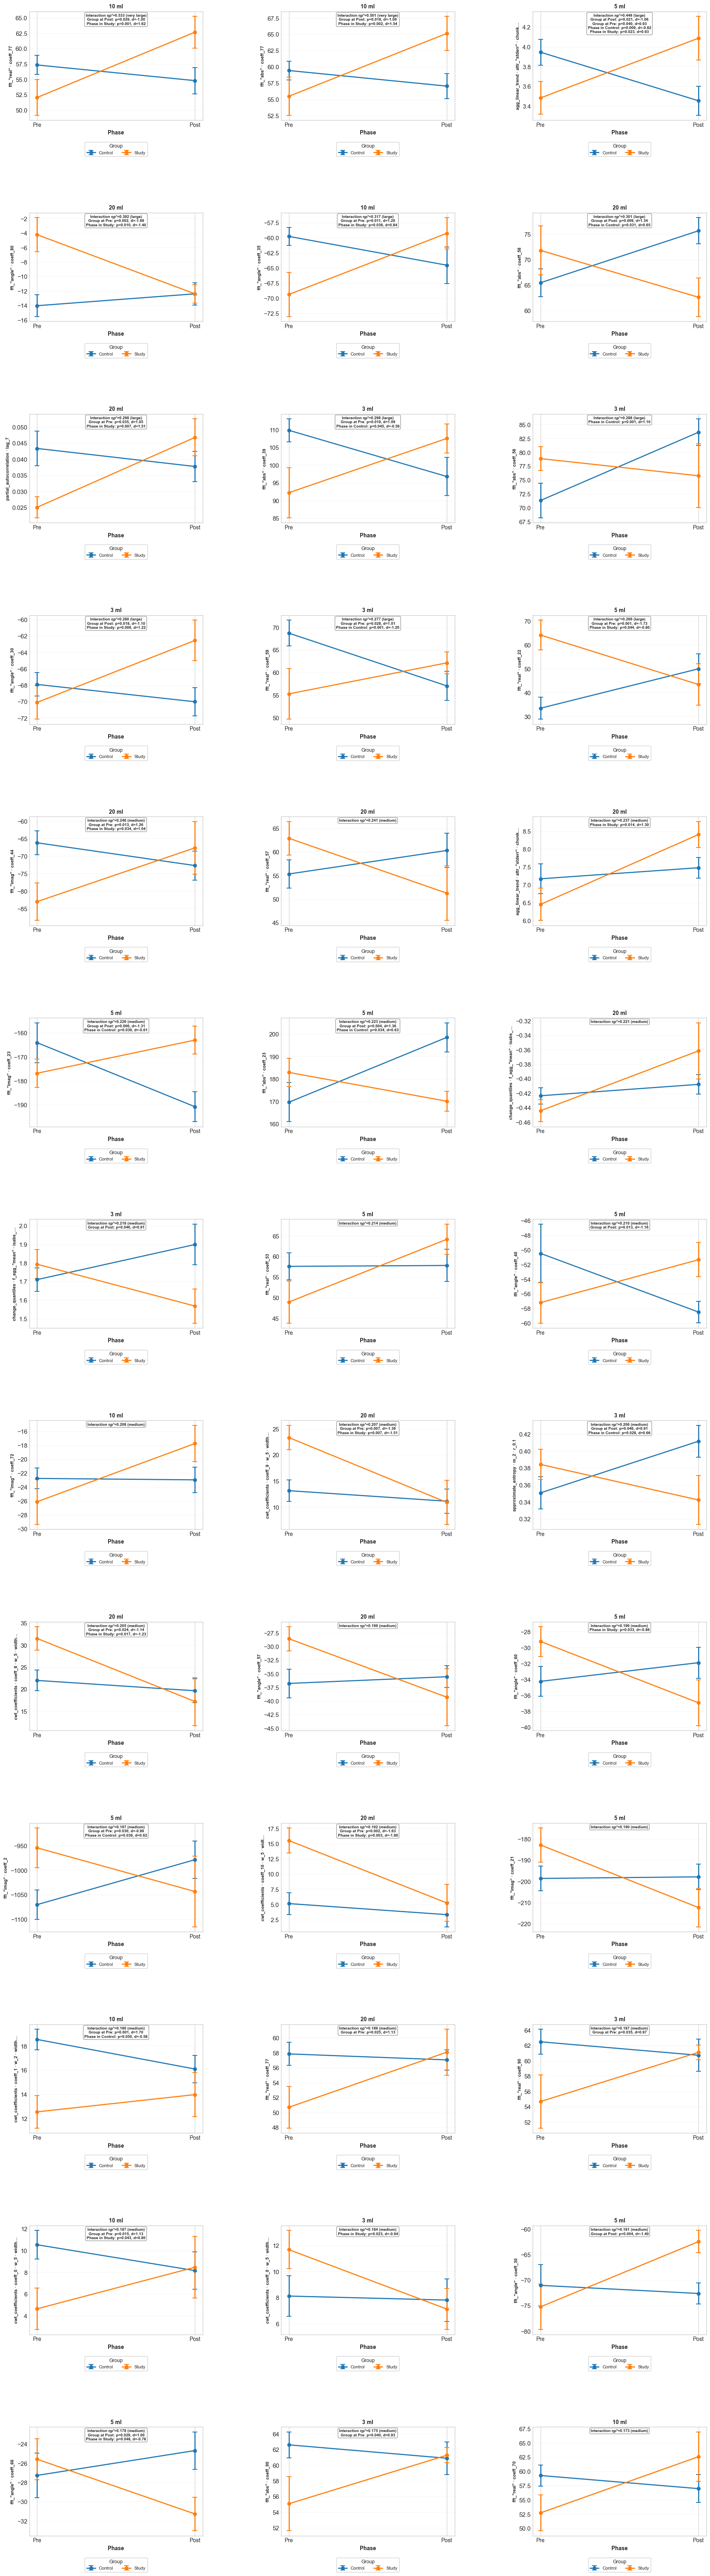


Total interaction plots: 39


In [162]:
# ── Compute simple effects ────────────────────────────────────────────

simple_results = []

for _, row in df_sig_interaction.iterrows():
    vol, feat = row['Volume (ml)'], row['Feature']
    df_vol = df_long[df_long['volume_ml'] == vol].copy()

    # 1) Simple effect of GROUP at each condition level (between-subjects)
    for cond in sorted(df_vol['condition'].unique()):
        subset = df_vol[df_vol['condition'] == cond]
        groups_data = [subset[subset['group'] == g][feat].dropna() for g in sorted(subset['group'].unique())]
        if all(len(g) >= 3 for g in groups_data):
            t_stat, p_val = ttest_ind(groups_data[0], groups_data[1])
            d = cohens_d_independent(groups_data[0], groups_data[1])
            df_t = len(groups_data[0]) + len(groups_data[1]) - 2
            eta2p = eta2p_from_t(t_stat, df_t)
            simple_results.append({
                'Volume (ml)': int(vol),
                'Feature': feat,
                'Test': f'Group effect at {cond}',
                'Group A': sorted(subset['group'].unique())[0],
                'Group B': sorted(subset['group'].unique())[1],
                'Mean A': round(groups_data[0].mean(), 4),
                'Mean B': round(groups_data[1].mean(), 4),
                'Mean Diff': round(groups_data[0].mean() - groups_data[1].mean(), 4),
                't': round(t_stat, 4),
                'df': df_t,
                'p': round(p_val, 4),
                'Cohen d': round(d, 4),
                'd label': effect_label_d(d),
                'ηp²': round(eta2p, 4),
                'ηp² label': effect_label_eta2p(eta2p),
            })

    # 2) Simple effect of CONDITION at each group level (within-subjects)
    for grp in sorted(df_vol['group'].unique()):
        subset = df_vol[df_vol['group'] == grp]
        cond_levels = sorted(subset['condition'].unique())
        if len(cond_levels) == 2:
            pre = subset[subset['condition'] == cond_levels[0]].set_index('subject')[feat].dropna()
            post = subset[subset['condition'] == cond_levels[1]].set_index('subject')[feat].dropna()
            common = pre.index.intersection(post.index)
            if len(common) >= 3:
                t_stat, p_val = ttest_rel(pre.loc[common], post.loc[common])
                d = cohens_d_paired(pre.loc[common].values, post.loc[common].values)
                df_t = len(common) - 1
                eta2p = eta2p_from_t(t_stat, df_t)
                simple_results.append({
                    'Volume (ml)': int(vol),
                    'Feature': feat,
                    'Test': f'Condition effect in {grp}',
                    'Group A': cond_levels[0],
                    'Group B': cond_levels[1],
                    'Mean A': round(pre.loc[common].mean(), 4),
                    'Mean B': round(post.loc[common].mean(), 4),
                    'Mean Diff': round(pre.loc[common].mean() - post.loc[common].mean(), 4),
                    't': round(t_stat, 4),
                    'df': df_t,
                    'p': round(p_val, 4),
                    'Cohen d': round(d, 4),
                    'd label': effect_label_d(d),
                    'ηp²': round(eta2p, 4),
                    'ηp² label': effect_label_eta2p(eta2p),
                })

df_simple = pd.DataFrame(simple_results)

# Significance at α = 0.05 (no multiple-comparison correction)
df_simple['Sig'] = df_simple['p'].apply(
    lambda p: '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
)

# ── Display tables ────────────────────────────────────────────────────

df_simple_sig = df_simple[df_simple['p'] < 0.05]
print(f"Simple effects: {len(df_simple_sig)} significant out of {len(df_simple)} total\n")

display_table(df_simple, "Simple Effects Analysis (Significant Interactions Only)")

if not df_simple_sig.empty:
    print(f"\n{'='*80}")
    print("EFFECT SIZE SUMMARY — Significant simple effects only")
    print(f"{'='*80}\n")
    es_summary = df_simple_sig[['Volume (ml)', 'Feature', 'Test', 'Cohen d', 'd label', 'ηp²', 'ηp² label', 'p']].copy()
    es_summary = es_summary.sort_values(['Volume (ml)', 'Feature'])
    display(es_summary.style
        .map(lambda v: 'background-color: #2d5f2d; color: white' if v in ['Large', 'Very large'] else '',
                  subset=['d label', 'ηp² label'])
        .set_properties(**{'font-size': '10px', 'text-align': 'center'})
    )

    # ── Export effect size summary to Word ──────────────────────────────
    # pip install python-docx   (if not already installed)
    from docx import Document
    from docx.shared import Pt, RGBColor, Inches
    from docx.enum.text import WD_ALIGN_PARAGRAPH
    from docx.enum.table import WD_TABLE_ALIGNMENT
    from docx.oxml.ns import qn
    from docx.oxml import OxmlElement

    def _shade_cell(cell, hex_color):
        """Apply background shading to a table cell (python-docx has no built-in API for this)."""
        shd = OxmlElement('w:shd')
        shd.set(qn('w:val'), 'clear')
        shd.set(qn('w:color'), 'auto')
        shd.set(qn('w:fill'), hex_color)
        cell._tc.get_or_add_tcPr().append(shd)

    doc = Document()
    doc.add_heading('Effect Size Summary — Significant Simple Effects', level=1)
    doc.add_paragraph(
        f'{len(es_summary)} significant simple effect comparisons (p < .05), '
        f'sorted by Volume and Feature.'
    )

    cols = ['Volume (ml)', 'Feature', 'Test', 'Cohen d', 'd label', 'ηp²', 'ηp² label', 'p']
    table = doc.add_table(rows=1, cols=len(cols))
    table.style = 'Table Grid'
    table.alignment = WD_TABLE_ALIGNMENT.CENTER

    # Header row
    for i, col_name in enumerate(cols):
        cell = table.rows[0].cells[i]
        cell.text = col_name
        run = cell.paragraphs[0].runs[0]
        run.font.bold = True
        run.font.size = Pt(9)
        _shade_cell(cell, 'D9D9D9')

    # Data rows
    for _, row_data in es_summary.iterrows():
        cells = table.add_row().cells
        for i, col_name in enumerate(cols):
            val = row_data[col_name]
            text = f'{val:.4f}' if isinstance(val, float) and col_name in ('Cohen d', 'ηp²', 'p') else str(val)
            cells[i].text = text
            run = cells[i].paragraphs[0].runs[0]
            run.font.size = Pt(9)
            cells[i].paragraphs[0].alignment = WD_ALIGN_PARAGRAPH.CENTER

            # Highlight Large/Very large the same way as the notebook styler
            if col_name in ('d label', 'ηp² label') and val in ('Large', 'Very large'):
                _shade_cell(cells[i], '2D5F2D')
                run.font.color.rgb = RGBColor(0xFF, 0xFF, 0xFF)

    # Auto-fit-ish column widths
    for i, width in enumerate([0.7, 2.6, 1.6, 0.8, 0.9, 0.7, 0.9, 0.6]):
        for row in table.rows:
            row.cells[i].width = Inches(width)

    word_path = NOTEBOOK_DIR / 'effect_size_summary.docx'
    doc.save(word_path)
    print(f"Word table saved to: {word_path}")

# ── Interaction plots ─────────────────────────────────────────────────

if len(sig_interactions) > 0:
    COND_LEVELS = ['Pre', 'Post']
    GROUP_COLORS = {'Control': '#1f77b4', 'Study': '#ff7f0e'}

    # Sort by effect size (largest first)
    plot_order = sig_interactions.sort_values('np2', ascending=False).reset_index(drop=True)

    n = len(plot_order)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)

    group_levels = sorted(df_long['group'].unique())

    for idx, (_, r) in enumerate(plot_order.iterrows()):
        ax = axes[idx // ncols][idx % ncols]
        vol, feat = r['Volume (ml)'], r['Feature']
        eta = r['np2']
        df_vol = df_long[df_long['volume_ml'] == vol]

        # --- Plot group lines with error bars ---
        for g in group_levels:
            means = [df_vol[(df_vol['condition'] == c) & (df_vol['group'] == g)][feat].mean()
                     for c in COND_LEVELS]
            sems  = [df_vol[(df_vol['condition'] == c) & (df_vol['group'] == g)][feat].sem()
                     for c in COND_LEVELS]
            ax.errorbar(range(len(COND_LEVELS)), means, yerr=sems,
                        marker='o', color=GROUP_COLORS[g], label=g,
                        linewidth=2, capsize=4, capthick=1.5)

        # --- X-axis labels ---
        ax.set_xticks(range(len(COND_LEVELS)))
        ax.set_xticklabels(COND_LEVELS, fontsize=10)
        ax.set_xlabel('Phase', fontsize=10, fontweight='bold')

        # --- Y-axis label: shortened feature name ---
        clean_name = (feat.replace('tsfresh_', '')
                          .replace('fft_coefficient__attr_', 'fft_')
                          .replace('__', ' · '))
        y_label = clean_name[:40] + '…' if len(clean_name) > 40 else clean_name
        ax.set_ylabel(y_label, fontsize=8, fontweight='bold')

        # --- Annotation box: ηp² + significant simple effects ---
        ann_lines = []
        if eta > 0.5:
            size_label = 'very large'
        elif eta > 0.25:
            size_label = 'large'
        elif eta > 0.05:
            size_label = 'medium'
        else:
            size_label = 'small'
        ann_lines.append(f"Interaction ηp²={eta:.3f} ({size_label})")

        feat_simple = df_simple[(df_simple['Feature'] == feat) &
                                (df_simple['Volume (ml)'] == vol)]
        for _, s in feat_simple.iterrows():
            if s['p'] < 0.05:
                if 'Group effect' in s['Test']:
                    phase = s['Test'].split('at ')[-1]
                    ann_lines.append(f"Group at {phase}: p={s['p']:.3f}, d={s['Cohen d']:.2f}")
                elif 'Condition effect' in s['Test']:
                    grp_name = s['Test'].split('in ')[-1]
                    ann_lines.append(f"Phase in {grp_name}: p={s['p']:.3f}, d={s['Cohen d']:.2f}")

        if ann_lines:
            ax.text(0.5, 0.98, '\n'.join(ann_lines),
                    transform=ax.transAxes, fontsize=7, fontweight='bold',
                    ha='center', va='top',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              edgecolor='gray', alpha=0.8))

        # --- Title ---
        ax.set_title(f"{int(vol)} ml", fontsize=10, fontweight='bold')

        # --- Grid ---
        ax.grid(axis='y', alpha=0.15)

        # --- Legend below each subplot ---
        ax.legend(title='Group', fontsize=8, title_fontsize=9,
                  loc='upper center', bbox_to_anchor=(0.5, -0.18),
                  ncol=2, frameon=True, framealpha=0.9)

    # Hide unused subplots
    for idx in range(n, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 1])
    plt.subplots_adjust(hspace=0.85, wspace=0.45)
    plt.savefig(NOTEBOOK_DIR / 'interaction_plots.png', dpi=600, bbox_inches='tight')
    plt.show()

    print(f"\nTotal interaction plots: {n}")

## 6. Non-Parametric tests (Wilcoxon, Friedman, Mann-Whintey)

In [163]:
# (friedmanchisquare, wilcoxon, mannwhitneyu imported in the imports cell)

friedman_results = []
wilcoxon_results = []
mannwhitney_results = []

_nonparam_errors = 0

for feat in nonparametric_features:

    # --- FRIEDMAN: across volumes, per group × condition ---
    for g in groups:
        for cond in conditions:
            sub = df_long[(df_long['group'] == g) & (df_long['condition'] == cond)]
            subj_per_vol = sub.groupby('volume_ml')['base_subject'].apply(set)
            if len(subj_per_vol) < 3:
                continue
            common_subjects = sorted(set.intersection(*subj_per_vol.values))
            if len(common_subjects) < 3:
                continue
            vol_data = []
            for vol in volumes:
                vol_sub = sub[sub['volume_ml'] == vol].set_index('base_subject')
                vol_data.append(vol_sub.loc[common_subjects, feat].values)
            try:
                stat, p = friedmanchisquare(*vol_data)
                friedman_results.append({
                    'Feature': feat,
                    'Group': g,
                    'Condition': cond,
                    'N subjects': len(common_subjects),
                    'Statistic': round(stat, 4),
                    'p-value': round(p, 4),
                    'Significant': '✓' if p < 0.05 else '',
                })
            except Exception:
                _nonparam_errors += 1

    # --- WILCOXON: pre vs post, per group × volume ---
    for g in groups:
        for vol in volumes:
            df_sub = df_long[(df_long['volume_ml'] == vol) & (df_long['group'] == g)]
            pre_df = df_sub[df_sub['condition'] == conditions[0]].set_index('subject')[feat].dropna()
            post_df = df_sub[df_sub['condition'] == conditions[1]].set_index('subject')[feat].dropna()
            common = pre_df.index.intersection(post_df.index)
            if len(common) >= 3:
                try:
                    stat, p = wilcoxon(pre_df.loc[common].values, post_df.loc[common].values)
                    wilcoxon_results.append({
                        'Feature': feat,
                        'Group': g,
                        'Volume (ml)': int(vol),
                        'N pairs': len(common),
                        'Statistic': round(stat, 4),
                        'p-value': round(p, 4),
                        'Significant': '✓' if p < 0.05 else '',
                    })
                except Exception:
                    _nonparam_errors += 1

    # --- MANN-WHITNEY: between groups, per volume × condition ---
    for vol in volumes:
        for cond in conditions:
            g1 = df_long[(df_long['volume_ml'] == vol) & (df_long['condition'] == cond) & (df_long['group'] == groups[0])][feat].dropna().values
            g2 = df_long[(df_long['volume_ml'] == vol) & (df_long['condition'] == cond) & (df_long['group'] == groups[1])][feat].dropna().values
            if len(g1) >= 2 and len(g2) >= 2:
                stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
                mannwhitney_results.append({
                    'Feature': feat,
                    'Volume (ml)': int(vol),
                    'Condition': cond,
                    'Statistic': round(stat, 4),
                    'p-value': round(p, 4),
                    'Significant': '✓' if p < 0.05 else '',
                })

if _nonparam_errors > 0:
    warnings.warn(
        f"{_nonparam_errors} exception(s) silently skipped in non-parametric loops. "
        "Some results may be incomplete.",
        UserWarning, stacklevel=2
    )

# --- Build full DataFrames and filter significant ---
df_friedman_all = pd.DataFrame(friedman_results)
df_wilcoxon_all = pd.DataFrame(wilcoxon_results)
df_mannwhitney_all = pd.DataFrame(mannwhitney_results)

df_friedman_sig = df_friedman_all[df_friedman_all['Significant'] == '✓'].copy() if len(df_friedman_all) > 0 else pd.DataFrame()
df_wilcoxon_sig = df_wilcoxon_all[df_wilcoxon_all['Significant'] == '✓'].copy() if len(df_wilcoxon_all) > 0 else pd.DataFrame()
df_mannwhitney_sig = df_mannwhitney_all[df_mannwhitney_all['Significant'] == '✓'].copy() if len(df_mannwhitney_all) > 0 else pd.DataFrame()

# --- Display only significant results ---
for name, df_all, df_sig in [('FRIEDMAN', df_friedman_all, df_friedman_sig),
                              ('WILCOXON', df_wilcoxon_all, df_wilcoxon_sig),
                              ('MANN-WHITNEY', df_mannwhitney_all, df_mannwhitney_sig)]:
    display_table(df_sig, f"{name} — Significant Results")
    sig_feats = sorted(df_sig['Feature'].unique()) if len(df_sig) > 0 else []
    print(f"  → {len(df_sig)} significant out of {len(df_all)} tests, "
          f"across {len(sig_feats)} features\n")

# --- Store for downstream use ---
sig_friedman_features = sorted(df_friedman_sig['Feature'].unique()) if len(df_friedman_sig) > 0 else []
sig_wilcoxon_features = sorted(df_wilcoxon_sig['Feature'].unique()) if len(df_wilcoxon_sig) > 0 else []
sig_mannwhitney_features = sorted(df_mannwhitney_sig['Feature'].unique()) if len(df_mannwhitney_sig) > 0 else []

# Aliases for downstream cells
df_friedman = df_friedman_all
df_wilcoxon = df_wilcoxon_all
df_mannwhitney = df_mannwhitney_all

c:\Users\Teresa\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Teresa\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Teresa\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Teresa\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Teresa\anaconda3\Lib\site-packages\scipy\stats\_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


Feature,Group,Condition,N subjects,Statistic,p-value,Significant
dtw_distance,Control,Post,14,12.6857,0.0054,✓
dtw_distance,Control,Pre,14,12.6857,0.0054,✓
energy,Control,Post,14,8.8286,0.0317,✓
energy,Control,Pre,14,8.5714,0.0356,✓
max,Control,Post,14,9.3429,0.0251,✓
max,Study,Pre,7,8.4857,0.0370,✓
std,Control,Post,14,9.8571,0.0198,✓
tsfresh_abs_energy,Control,Post,14,8.8286,0.0317,✓
tsfresh_abs_energy,Control,Pre,14,8.5714,0.0356,✓
"tsfresh_agg_autocorrelation__f_agg_""median""__maxlag_40",Study,Post,7,7.9714,0.0466,✓


  → 126 significant out of 2088 tests, across 113 features



Feature,Group,Volume (ml),N pairs,Statistic,p-value,Significant
kurtosis,Study,20,7,2.0,0.0469,✓
std,Study,20,7,0.0,0.0156,✓
tsfresh_absolute_sum_of_changes,Control,3,14,3.0,0.0006,✓
"tsfresh_agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""var""",Study,20,7,2.0,0.0469,✓
"tsfresh_agg_linear_trend__attr_""intercept""__chunk_len_5__f_agg_""var""",Control,20,14,21.0,0.0494,✓
"tsfresh_agg_linear_trend__attr_""intercept""__chunk_len_5__f_agg_""var""",Study,20,7,0.0,0.0156,✓
"tsfresh_agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""max""",Study,20,7,2.0,0.0469,✓
"tsfresh_agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""mean""",Study,20,7,1.0,0.0312,✓
"tsfresh_agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""min""",Study,20,7,0.0,0.0156,✓
"tsfresh_agg_linear_trend__attr_""rvalue""__chunk_len_10__f_agg_""var""",Control,20,14,15.0,0.0166,✓


  → 265 significant out of 4176 tests, across 212 features



Feature,Volume (ml),Condition,Statistic,p-value,Significant
dtw_distance,3,Post,22.0,0.0107,✓
dtw_distance,3,Pre,22.0,0.0107,✓
energy,10,Post,27.0,0.0253,✓
energy,10,Pre,31.0,0.0472,✓
iqr,20,Post,77.0,0.0379,✓
kurtosis,20,Post,19.0,0.0250,✓
median,10,Post,102.0,0.0153,✓
min,10,Post,95.0,0.0472,✓
std,20,Post,86.0,0.0042,✓
tsfresh_abs_energy,10,Post,27.0,0.0253,✓


  → 269 significant out of 4176 tests, across 208 features



### 6.1. Non-parametric results - Radar plot

RADAR PLOT 1 — FRIEDMAN (significant features by family)


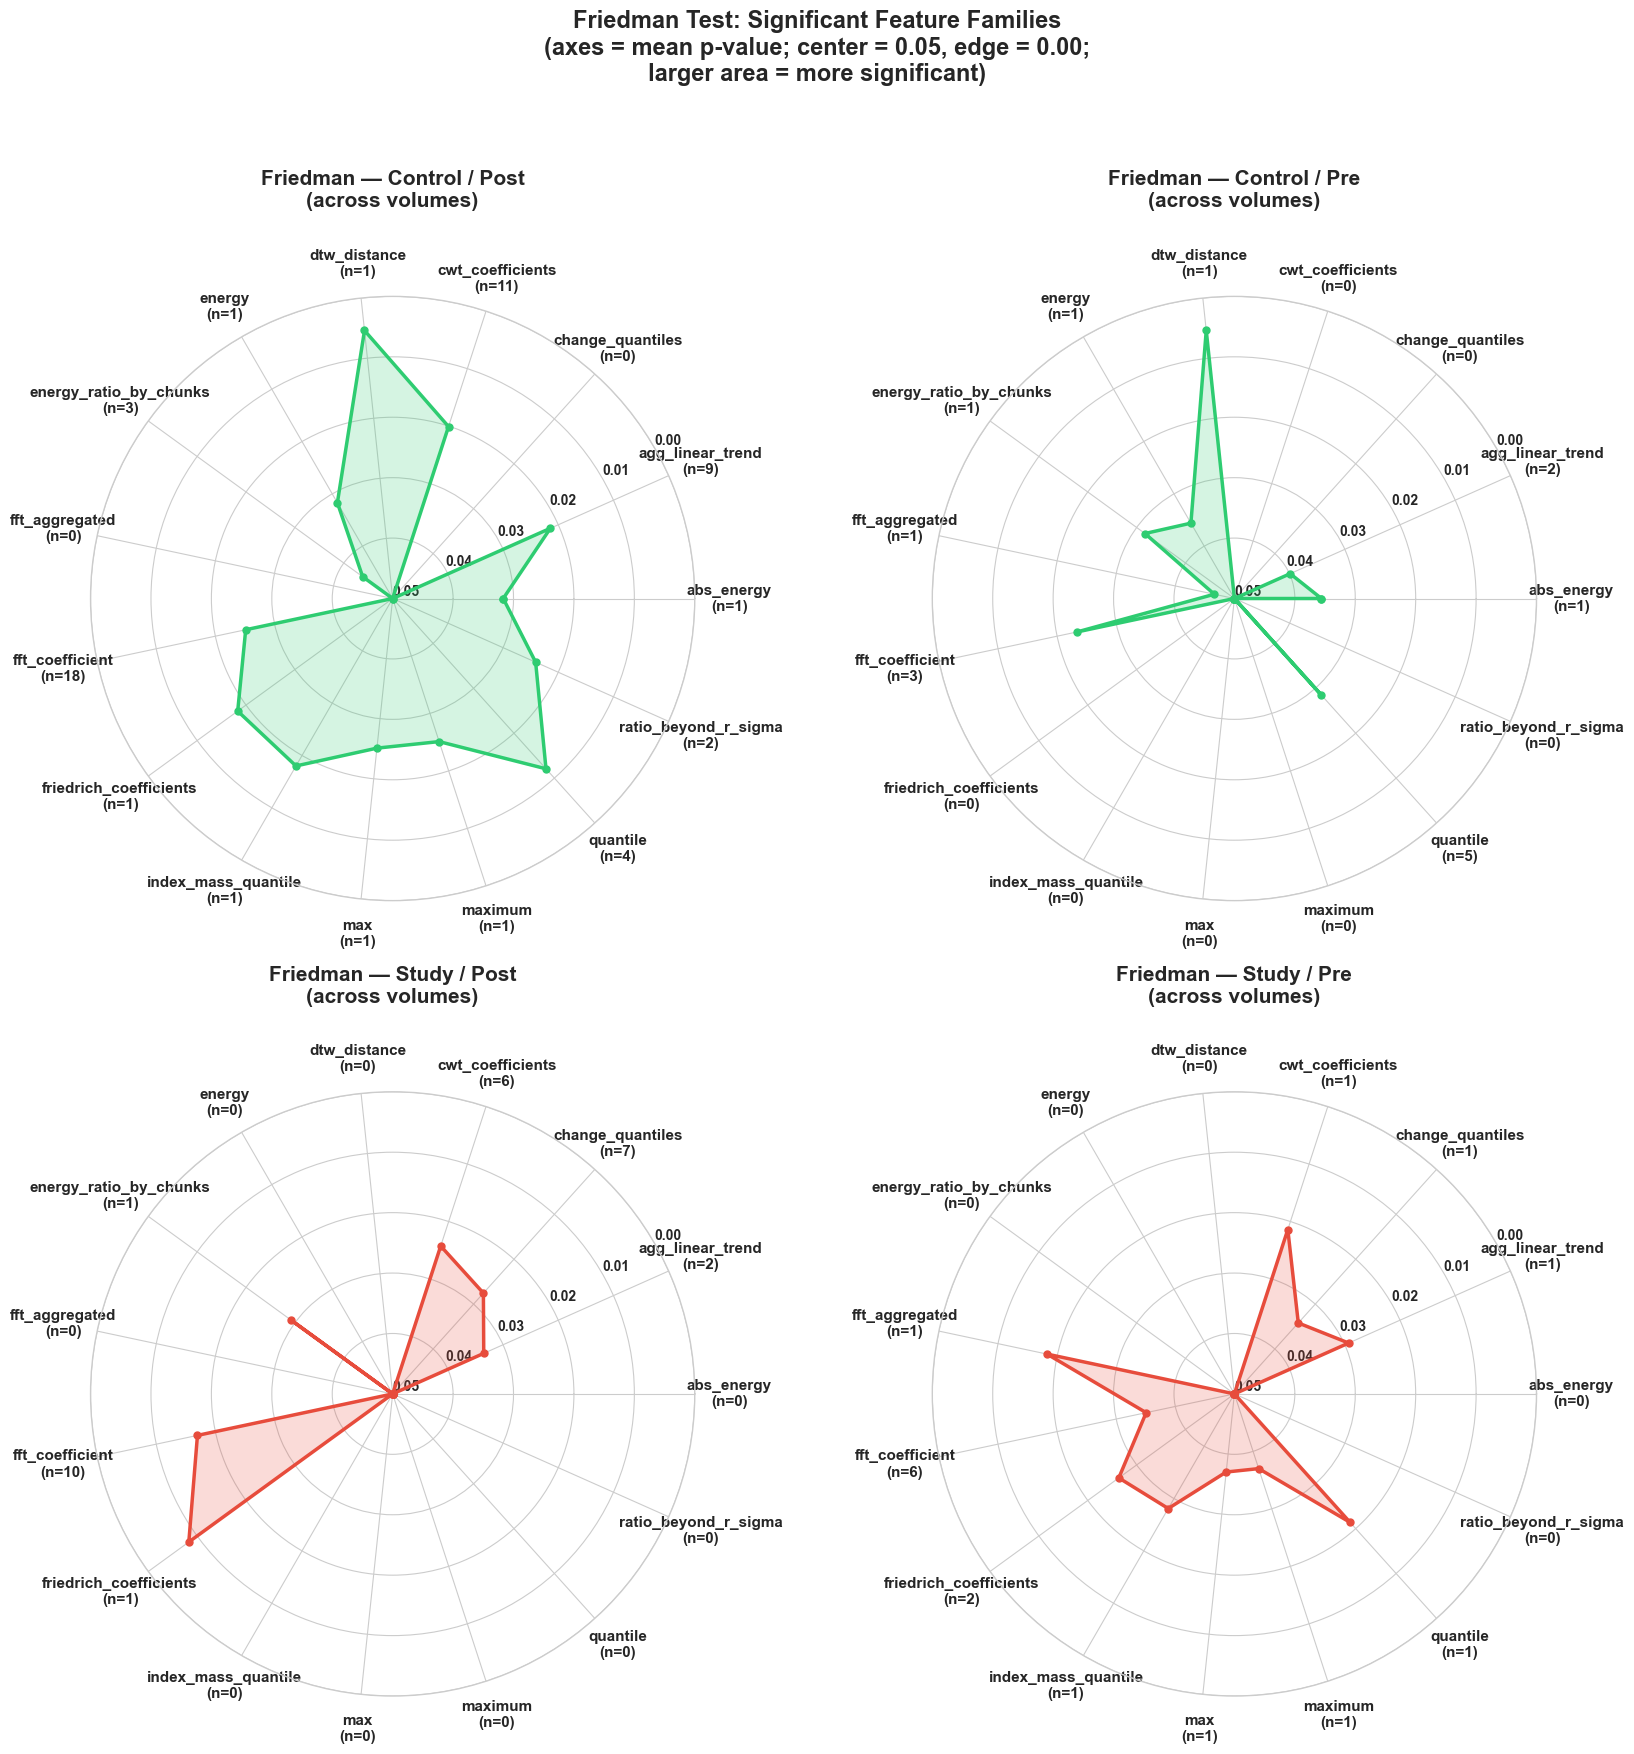


RADAR PLOT 2 — WILCOXON (significant features by family x volume)


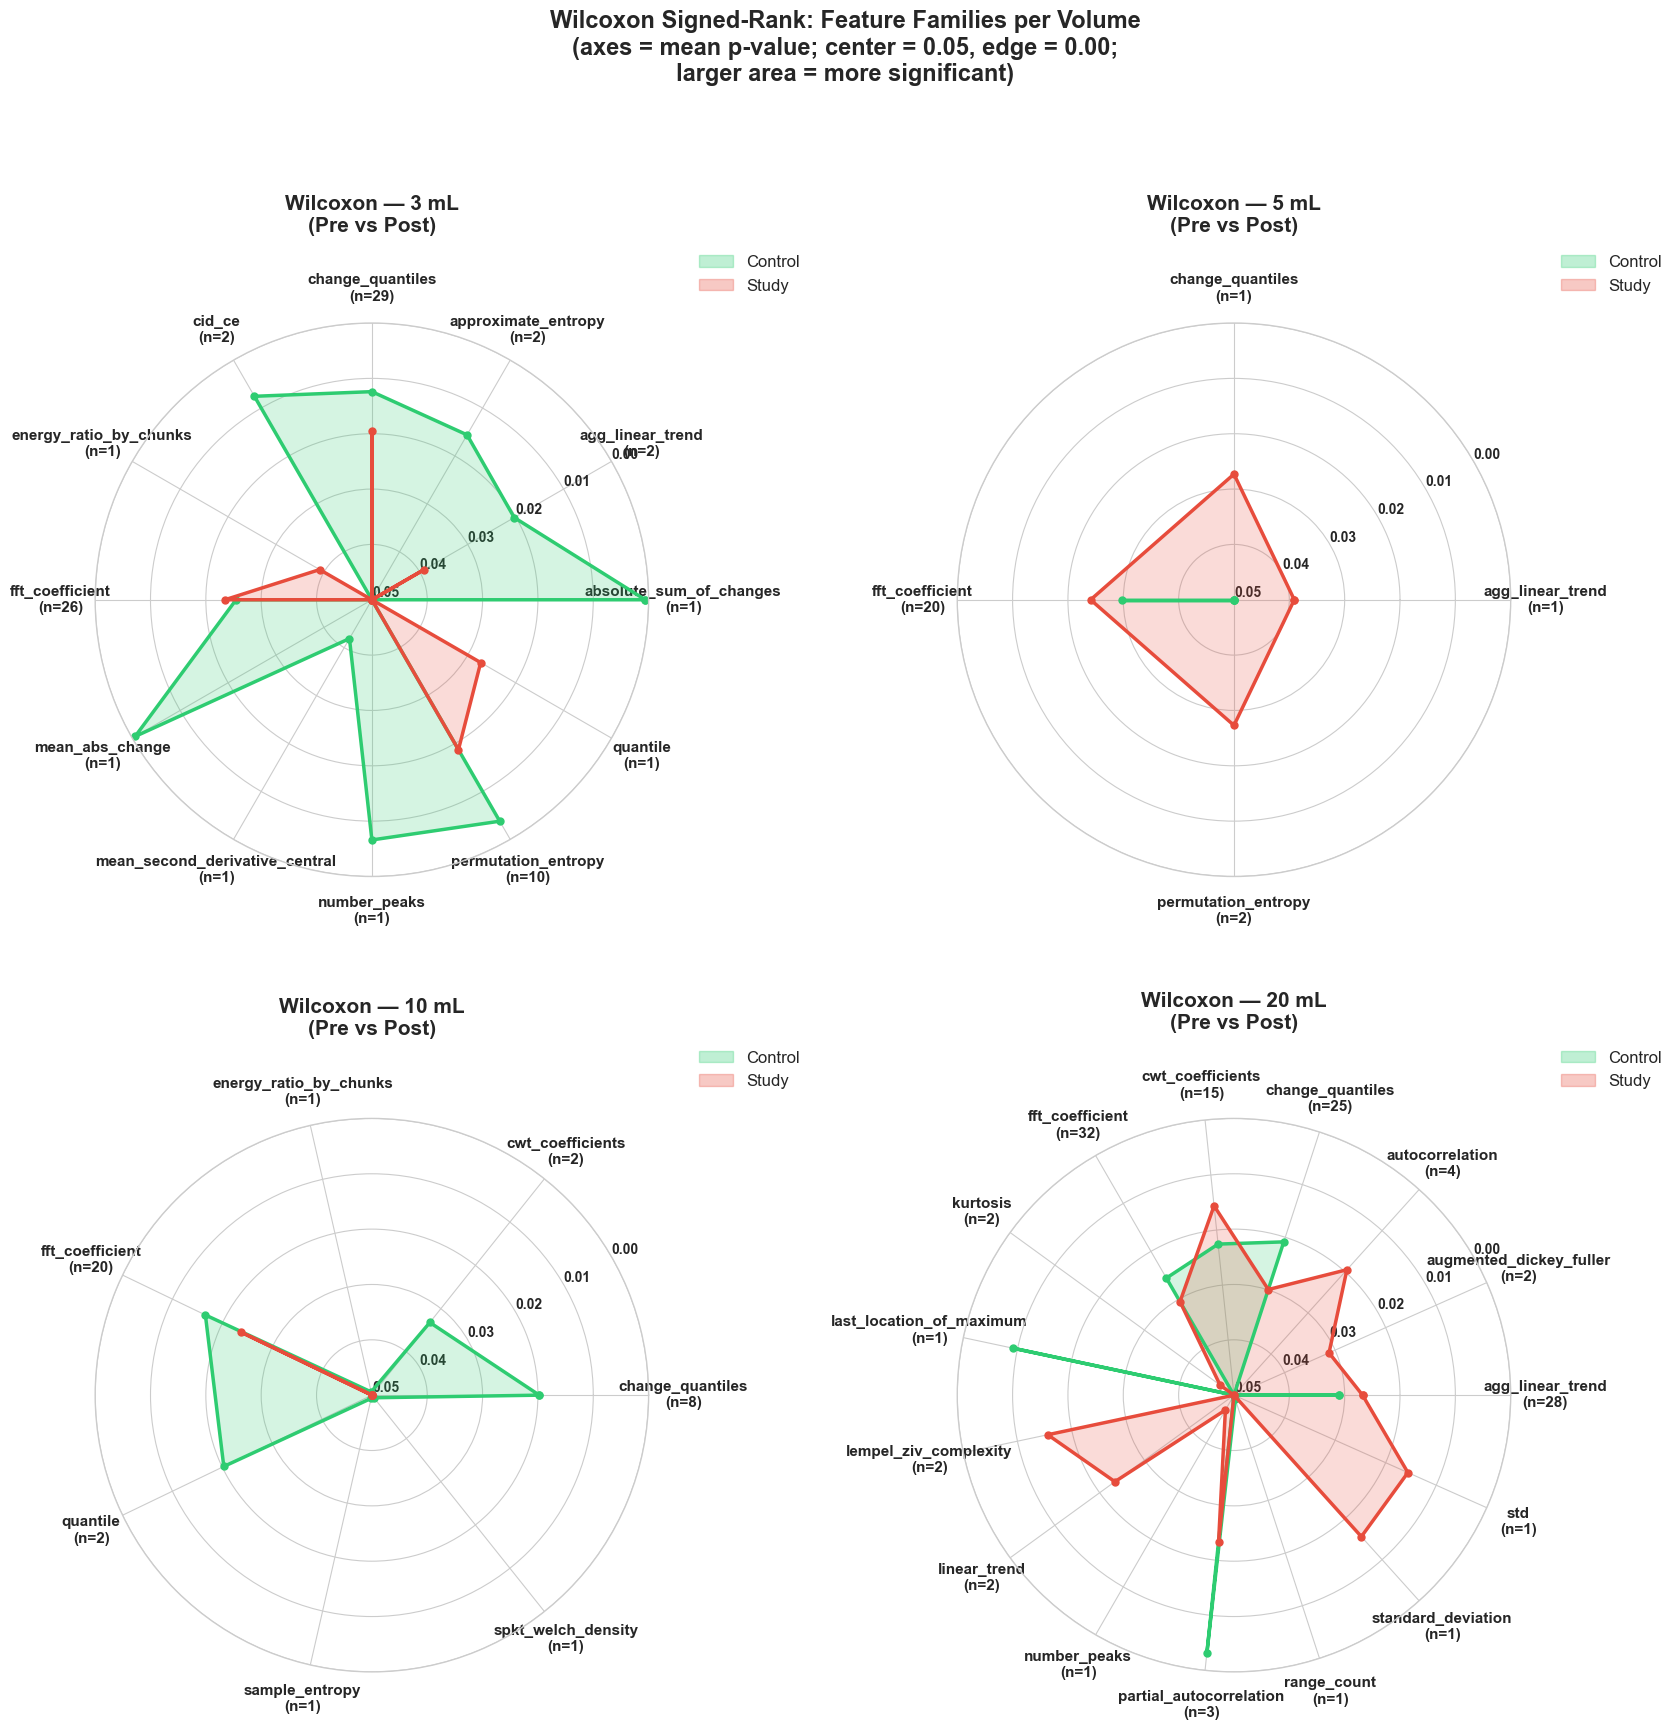


RADAR PLOT 3 — MANN-WHITNEY (significant features by family x volume)


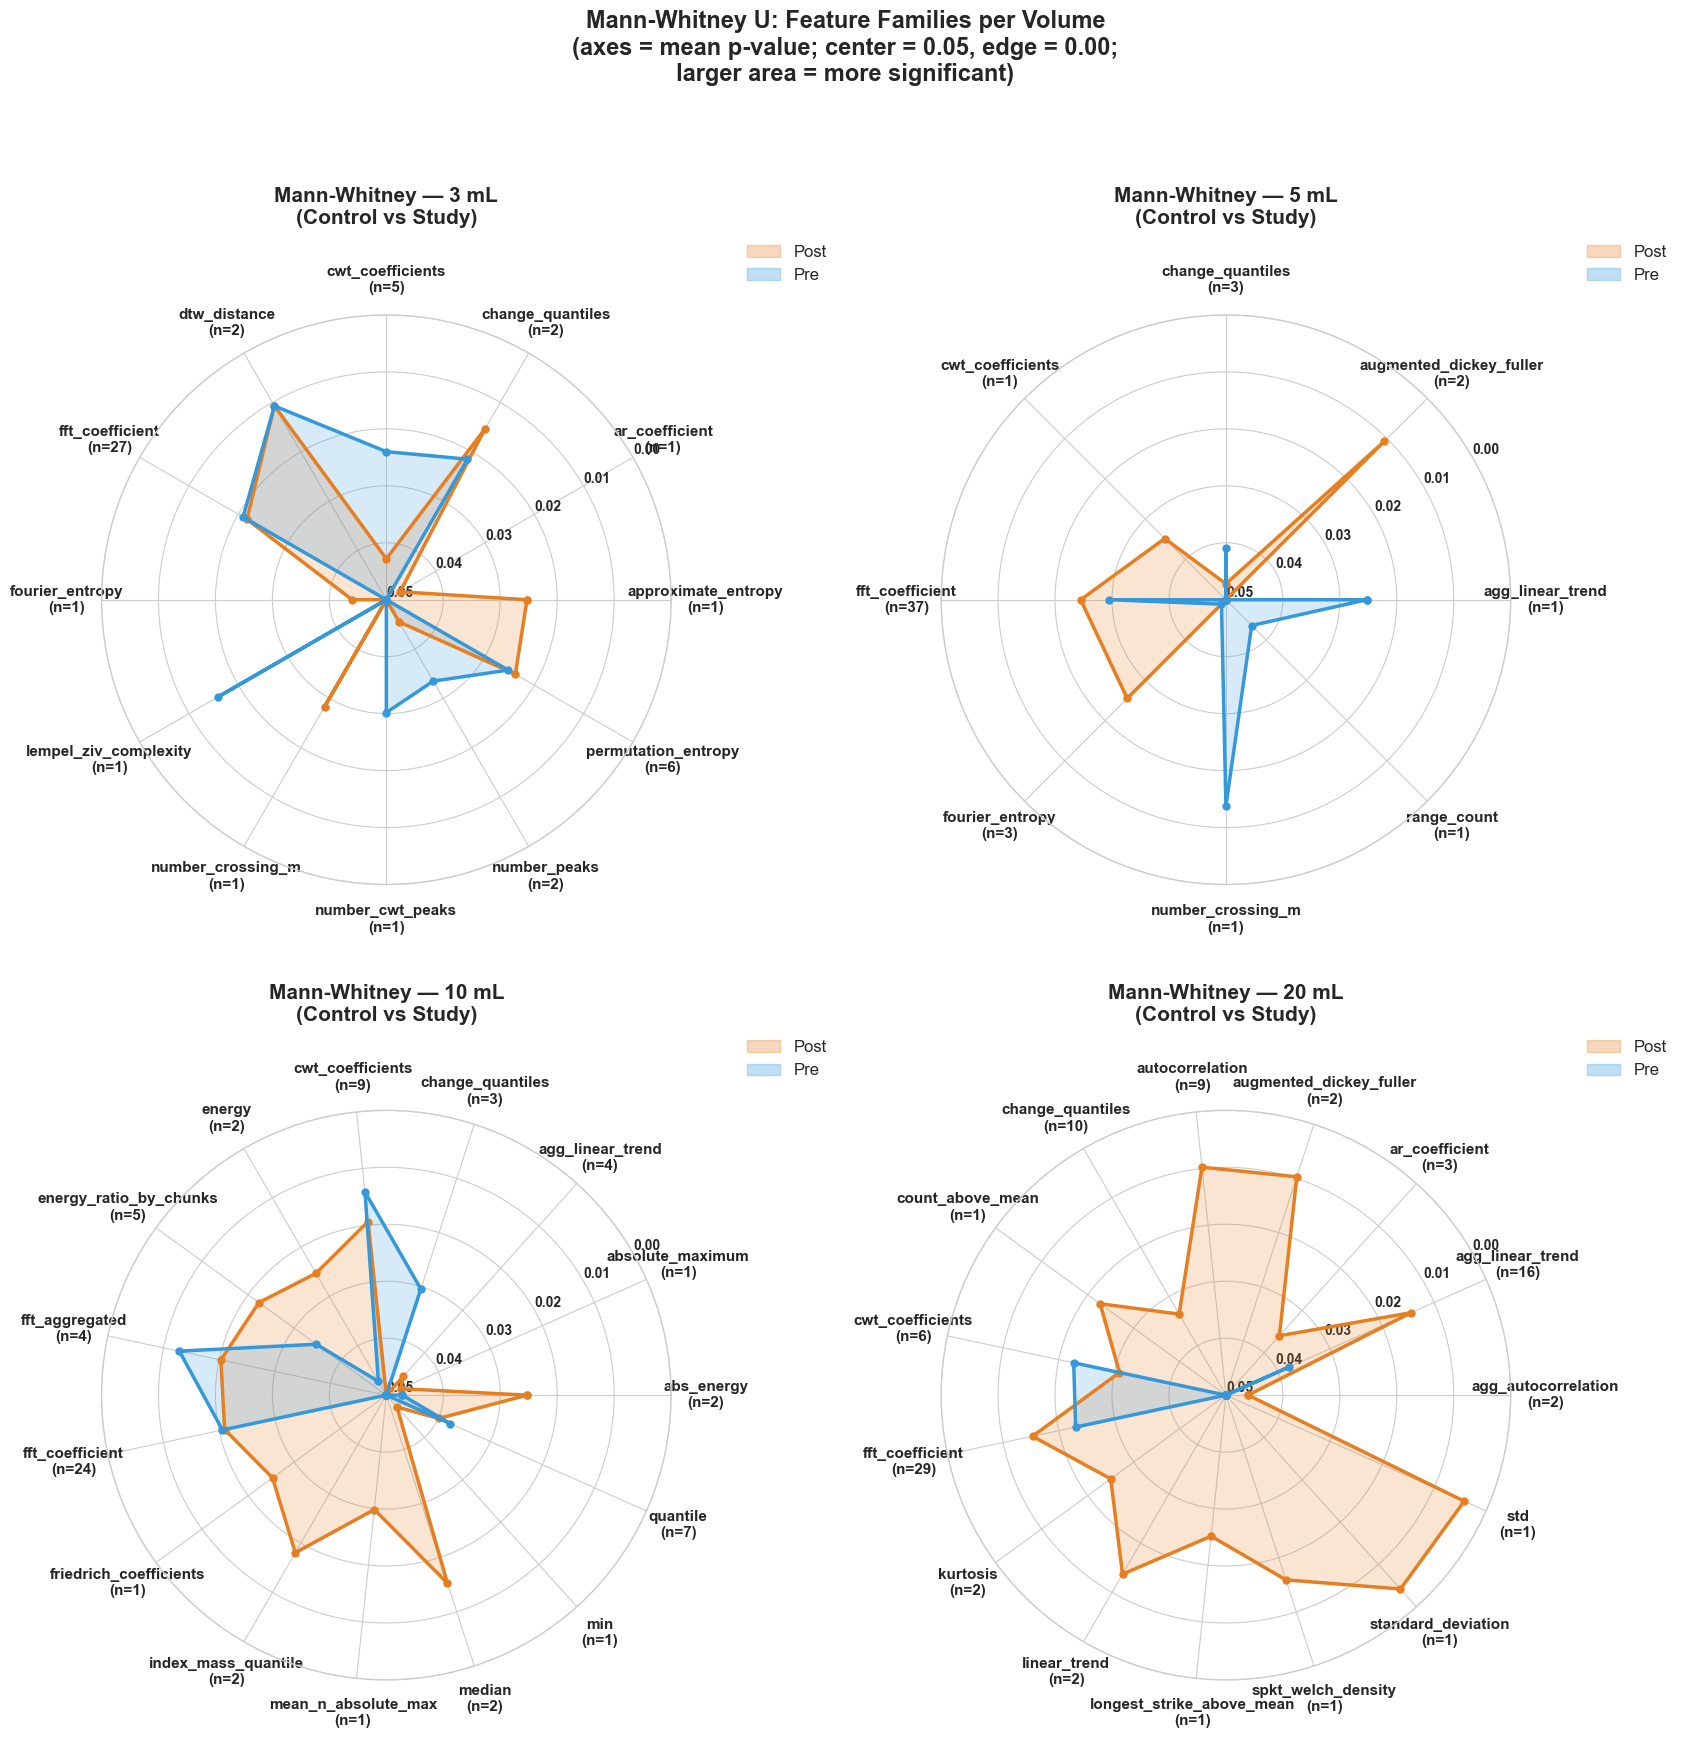


✓ Radar plots complete.


In [164]:
# ============================================================
# 6.2. Radar Plots — Feature Families × Non-Parametric p-values
# ============================================================
# Scale: 0.05 at center (barely significant), 0.00 at edge (highly significant).
# Larger area = more significant.
# Families with n=0 collapse to center (invisible).
# All groups share the same axes (union of top families).
# Layout: 2x2 grid per figure (instead of 1xN) so panels stay square
# and enlarge cleanly when resized in Word.

# ── Helper: map a feature name to its family ──────────────────────
def feature_to_family(feat_name):
    if feat_name.startswith('tsfresh_'):
        stripped = feat_name.replace('tsfresh_', '', 1)
        return stripped.split('__')[0]
    return feat_name


def add_family_column(df):
    df = df.copy()
    df['Family'] = df['Feature'].apply(feature_to_family)
    return df


def get_top_families(df_sig, max_families=15):
    """Get the top N families by count (keeps radar readable)."""
    df = add_family_column(df_sig)
    family_counts = df.groupby('Family').size().sort_values(ascending=False)
    return sorted(family_counts.head(max_families).index.tolist())


def build_radar_data_unified(df_sub, all_families, value_col='p-value'):
    """
    Build radar values aligned to a shared set of families.
    Returns INVERTED values: 0.05 - mean_p (bigger = more significant).
    Missing families (n=0) get 0.0 → collapse to center.
    """
    df = add_family_column(df_sub)
    grouped = df.groupby('Family').agg(
        mean_p=(value_col, 'mean'),
        count=(value_col, 'count')
    )
    values, counts = [], []
    for fam in all_families:
        if fam in grouped.index:
            values.append(0.05 - grouped.loc[fam, 'mean_p'])
            counts.append(int(grouped.loc[fam, 'count']))
        else:
            values.append(0.0)
            counts.append(0)
    return np.array(values), counts


def draw_radar_trace(ax, angles, values, color):
    """Draw a single radar trace (fill + line)."""
    values_closed = np.append(values, values[0])
    angles_closed = angles + [angles[0]]
    ax.fill(angles_closed, values_closed, alpha=0.20, color=color)
    ax.plot(angles_closed, values_closed, 'o-', color=color,
            linewidth=2.5, markersize=5)


def format_radar_axes(ax, angles, all_families, total_counts, title):
    """Apply labels, ticks, and formatting (call once per subplot)."""
    labels = [f'{fam}\n(n={c})' for fam, c in zip(all_families, total_counts)]
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=11, fontweight='bold', ha='center')
    ax.tick_params(axis='x', pad=18)  # push labels out so bigger text doesn't crowd the circle
    ax.set_title(title, fontsize=15, fontweight='bold', pad=30)
    ax.set_rlim(0, 0.05)
    ax.set_rticks([0.00, 0.01, 0.02, 0.03, 0.04, 0.05])
    ax.set_yticklabels(['0.05', '0.04', '0.03', '0.02', '0.01', '0.00'],
                       fontsize=10, fontweight='bold')
    ax.set_rlabel_position(30)
    ax.set_ylabel('')


def make_2x2_grid(n_panels, panel_size=8.5):
    """
    Create a 2x2 polar-subplot grid sized for n_panels (<=4).
    Returns (fig, list_of_axes_in_order, list_of_unused_axes_to_hide).
    """
    fig, axes = plt.subplots(2, 2, figsize=(panel_size * 2, panel_size * 2),
                             subplot_kw=dict(polar=True))
    axes_flat = axes.flatten().tolist()
    used = axes_flat[:n_panels]
    unused = axes_flat[n_panels:]
    return fig, used, unused


MAX_FAMILIES = 15


# ============================================================
# PLOT 1 — FRIEDMAN: one radar per Group x Condition (2x2 grid)
# ============================================================
print("=" * 60)
print("RADAR PLOT 1 — FRIEDMAN (significant features by family)")
print("=" * 60)

df_fr_sig = df_friedman[df_friedman['Significant'] == '✓'].copy() if len(df_friedman) > 0 else pd.DataFrame()

if len(df_fr_sig) >= 1:
    all_families = get_top_families(df_fr_sig, MAX_FAMILIES)

    if len(all_families) < 3:
        print("  < 3 feature families total — skipped.")
    else:
        combos = df_fr_sig.groupby(['Group', 'Condition']).size().reset_index()
        combos.columns = ['Group', 'Condition', 'count']
        plottable = [(row['Group'], row['Condition']) for _, row in combos.iterrows()][:4]

        fig, axes, unused = make_2x2_grid(len(plottable))

        colors_gc = {'Control': '#2ecc71', 'Study': '#e74c3c'}
        angles = np.linspace(0, 2 * np.pi, len(all_families),
                             endpoint=False).tolist()

        for idx, (g, cond) in enumerate(plottable):
            ax = axes[idx]
            sub = df_fr_sig[(df_fr_sig['Group'] == g) &
                            (df_fr_sig['Condition'] == cond)]
            vals, cnts = build_radar_data_unified(sub, all_families)
            c = colors_gc.get(g, '#2980b9')
            draw_radar_trace(ax, angles, vals, c)
            format_radar_axes(ax, angles, all_families, cnts,
                              f'Friedman — {g} / {cond}\n(across volumes)')

        for ax in unused:
            ax.set_visible(False)

        fig.suptitle('Friedman Test: Significant Feature Families\n'
                     '(axes = mean p-value; center = 0.05, edge = 0.00;\n'
                     'larger area = more significant)',
                     fontsize=17, fontweight='bold', y=1.03)
        plt.tight_layout()
        plt.show()
else:
    print("  No significant Friedman results to plot.")


# ============================================================
# PLOT 2 — WILCOXON: one radar per Volume, coloured by Group (2x2 grid)
# ============================================================
print("\n" + "=" * 60)
print("RADAR PLOT 2 — WILCOXON (significant features by family x volume)")
print("=" * 60)

df_wil_sig = df_wilcoxon[df_wilcoxon['Significant'] == '✓'].copy() if len(df_wilcoxon) > 0 else pd.DataFrame()

if len(df_wil_sig) >= 1:
    vol_list = sorted(df_wil_sig['Volume (ml)'].unique())
    grp_list = sorted(df_wil_sig['Group'].unique())
    colors_grp = {'Control': '#2ecc71', 'Study': '#e74c3c'}

    plottable_vols = []
    for vol in vol_list:
        sub_vol = df_wil_sig[df_wil_sig['Volume (ml)'] == vol]
        fams = get_top_families(sub_vol, MAX_FAMILIES)
        if len(fams) >= 3:
            plottable_vols.append(vol)
    plottable_vols = plottable_vols[:4]

    if len(plottable_vols) == 0:
        print("  No volumes with >= 3 feature families to plot.")
    else:
        fig, axes, unused = make_2x2_grid(len(plottable_vols))

        for vi, vol in enumerate(plottable_vols):
            ax = axes[vi]
            sub_vol = df_wil_sig[df_wil_sig['Volume (ml)'] == vol]
            all_families = get_top_families(sub_vol, MAX_FAMILIES)
            angles = np.linspace(0, 2 * np.pi, len(all_families),
                                 endpoint=False).tolist()

            legend_handles = []
            total_counts = [0] * len(all_families)

            for g in grp_list:
                sub = sub_vol[sub_vol['Group'] == g]
                if len(sub) == 0:
                    continue
                vals, cnts = build_radar_data_unified(sub, all_families)
                total_counts = [t + c for t, c in zip(total_counts, cnts)]
                c = colors_grp.get(g, '#2980b9')
                draw_radar_trace(ax, angles, vals, c)
                legend_handles.append(mpatches.Patch(color=c, alpha=0.3, label=g))

            format_radar_axes(ax, angles, all_families, total_counts,
                              f'Wilcoxon — {vol} mL\n(Pre vs Post)')
            if legend_handles:
                ax.legend(handles=legend_handles, loc='upper right',
                          bbox_to_anchor=(1.3, 1.15), fontsize=12)

        for ax in unused:
            ax.set_visible(False)

        skipped = [v for v in vol_list if v not in plottable_vols]
        if skipped:
            print(f"  Skipped volumes (< 3 families): {skipped}")

        fig.suptitle('Wilcoxon Signed-Rank: Feature Families per Volume\n'
                     '(axes = mean p-value; center = 0.05, edge = 0.00;\n'
                     'larger area = more significant)',
                     fontsize=17, fontweight='bold', y=1.03)
        plt.tight_layout()
        plt.show()
else:
    print("  No significant Wilcoxon results to plot.")


# ============================================================
# PLOT 3 — MANN-WHITNEY: one radar per Volume, coloured by Condition (2x2 grid)
# ============================================================
print("\n" + "=" * 60)
print("RADAR PLOT 3 — MANN-WHITNEY (significant features by family x volume)")
print("=" * 60)

df_mw_sig = df_mannwhitney[df_mannwhitney['Significant'] == '✓'].copy() if len(df_mannwhitney) > 0 else pd.DataFrame()

if len(df_mw_sig) >= 1:
    vol_list = sorted(df_mw_sig['Volume (ml)'].unique())
    cond_list = sorted(df_mw_sig['Condition'].unique())
    colors_cond = {'Pre': '#3498db', 'Post': '#e67e22'}

    plottable_vols = []
    for vol in vol_list:
        sub_vol = df_mw_sig[df_mw_sig['Volume (ml)'] == vol]
        fams = get_top_families(sub_vol, MAX_FAMILIES)
        if len(fams) >= 3:
            plottable_vols.append(vol)
    plottable_vols = plottable_vols[:4]

    if len(plottable_vols) == 0:
        print("  No volumes with >= 3 feature families to plot.")
    else:
        fig, axes, unused = make_2x2_grid(len(plottable_vols))

        for vi, vol in enumerate(plottable_vols):
            ax = axes[vi]
            sub_vol = df_mw_sig[df_mw_sig['Volume (ml)'] == vol]
            all_families = get_top_families(sub_vol, MAX_FAMILIES)
            angles = np.linspace(0, 2 * np.pi, len(all_families),
                                 endpoint=False).tolist()

            legend_handles = []
            total_counts = [0] * len(all_families)

            for cond in cond_list:
                sub = sub_vol[sub_vol['Condition'] == cond]
                if len(sub) == 0:
                    continue
                vals, cnts = build_radar_data_unified(sub, all_families)
                total_counts = [t + c for t, c in zip(total_counts, cnts)]
                c = colors_cond.get(cond, '#2980b9')
                draw_radar_trace(ax, angles, vals, c)
                legend_handles.append(mpatches.Patch(color=c, alpha=0.3, label=cond))

            format_radar_axes(ax, angles, all_families, total_counts,
                              f'Mann-Whitney — {vol} mL\n(Control vs Study)')
            if legend_handles:
                ax.legend(handles=legend_handles, loc='upper right',
                          bbox_to_anchor=(1.3, 1.15), fontsize=12)

        for ax in unused:
            ax.set_visible(False)

        skipped = [v for v in vol_list if v not in plottable_vols]
        if skipped:
            print(f"  Skipped volumes (< 3 families): {skipped}")

        fig.suptitle('Mann-Whitney U: Feature Families per Volume\n'
                     '(axes = mean p-value; center = 0.05, edge = 0.00;\n'
                     'larger area = more significant)',
                     fontsize=17, fontweight='bold', y=1.03)
        plt.tight_layout()
        plt.show()
else:
    print("  No significant Mann-Whitney results to plot.")

print("\n✓ Radar plots complete.")

### 7. Export summary excel file with the results of the previous analysis

In [165]:
# ══════════════════════════════════════════════════════════════════════
# EXPORT ALL STATISTICAL TABLES TO EXCEL
# ══════════════════════════════════════════════════════════════════════

OUTPUT_PATH = NOTEBOOK_DIR / 'statistical_results.xlsx'

wb = Workbook()
wb.remove(wb.active)

# ── Styling ───────────────────────────────────────────────────────────
HEADER_FONT = Font(name='Arial', bold=True, size=10, color='FFFFFF')
HEADER_FILL = PatternFill('solid', fgColor='2F5496')
SIG_FILL = PatternFill('solid', fgColor='D5E8D4')  # light green for significant rows
DATA_FONT = Font(name='Arial', size=10)
THIN_BORDER = Border(
    bottom=Side(style='thin', color='D9D9D9')
)
CENTER = Alignment(horizontal='center', vertical='center')
LEFT = Alignment(horizontal='left', vertical='center')


def write_sheet(wb, name, df, sig_col=None):
    """Write a DataFrame to a formatted Excel sheet.
    
    Parameters
    ----------
    wb : Workbook
    name : str          Sheet name (max 31 chars).
    df : pd.DataFrame   Data to write.
    sig_col : str|None  Column name used to highlight significant rows (green).
    """
    if df is None or len(df) == 0:
        return
    ws = wb.create_sheet(title=name[:31])

    # Write header
    for c_idx, col_name in enumerate(df.columns, 1):
        cell = ws.cell(row=1, column=c_idx, value=col_name)
        cell.font = HEADER_FONT
        cell.fill = HEADER_FILL
        cell.alignment = CENTER

    # Write data
    for r_idx, (_, row) in enumerate(df.iterrows(), 2):
        is_sig = False
        if sig_col and sig_col in df.columns:
            val = row[sig_col]
            is_sig = val in [True, '✓', '*', '**', '***']

        for c_idx, col_name in enumerate(df.columns, 1):
            cell = ws.cell(row=r_idx, column=c_idx, value=row[col_name])
            cell.font = DATA_FONT
            cell.border = THIN_BORDER
            cell.alignment = CENTER

            if is_sig:
                cell.fill = SIG_FILL

    # Auto-fit column widths
    for c_idx, col_name in enumerate(df.columns, 1):
        max_len = len(str(col_name))
        for r_idx in range(2, min(len(df) + 2, 102)):  # sample first 100 rows
            val = ws.cell(row=r_idx, column=c_idx).value
            if val is not None:
                max_len = max(max_len, len(str(val)))
        ws.column_dimensions[ws.cell(row=1, column=c_idx).column_letter].width = min(max_len + 3, 40)

    # Freeze header row
    ws.freeze_panes = 'A2'
    # Auto-filter
    ws.auto_filter.ref = ws.dimensions


# ── Clean feature names ────────────────────────────────────────────────

def clean_feature_names(df):
    """Strip 'tsfresh_' prefix from Feature-like columns for readability."""
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == object:
            mask = df[col].str.startswith('tsfresh_', na=False)
            if mask.any():
                df[col] = df[col].str.replace(r'^tsfresh_', '', regex=True)
    return df


# ── Collect all tables ────────────────────────────────────────────────

sheets = []

# ANOVA results
if 'df_anova' in dir():
    sheets.append(('ANOVA - All', clean_feature_names(df_anova), 'Significant'))
    df_anova_sig = df_anova[df_anova['Significant'] == '✓']
    if len(df_anova_sig) > 0:
        sheets.append(('ANOVA - Significant', clean_feature_names(df_anova_sig), 'Significant'))

# Tukey HSD
if 'df_tukey' in dir() and len(df_tukey) > 0:
    sheets.append(('Tukey - All', clean_feature_names(df_tukey), 'Reject'))
if 'df_tukey_sig' in dir() and len(df_tukey_sig) > 0:
    sheets.append(('Tukey - Significant', clean_feature_names(df_tukey_sig), 'Reject'))

# Simple effects
if 'df_simple' in dir() and len(df_simple) > 0:
    sheets.append(('Simple Effects - All', clean_feature_names(df_simple), 'Sig'))
    if 'df_simple_sig' in dir() and len(df_simple_sig) > 0:
        sheets.append(('Simple Effects - Sig', clean_feature_names(df_simple_sig), 'Sig'))

# Friedman
for name in ['df_friedman_all', 'df_friedman']:
    if name in dir():
        df_fr = eval(name)
        if len(df_fr) > 0:
            sheets.append(('Friedman - All', clean_feature_names(df_fr), 'Significant'))
            df_fr_sig = df_fr[df_fr['Significant'] == '✓']
            if len(df_fr_sig) > 0:
                sheets.append(('Friedman - Significant', clean_feature_names(df_fr_sig), 'Significant'))
        break

# Wilcoxon
for name in ['df_wilcoxon_all', 'df_wilcoxon']:
    if name in dir():
        df_wil = eval(name)
        if len(df_wil) > 0:
            sheets.append(('Wilcoxon - All', clean_feature_names(df_wil), 'Significant'))
            df_wil_sig = df_wil[df_wil['Significant'] == '✓']
            if len(df_wil_sig) > 0:
                sheets.append(('Wilcoxon - Significant', clean_feature_names(df_wil_sig), 'Significant'))
        break

# Mann-Whitney
for name in ['df_mannwhitney_all', 'df_mannwhitney']:
    if name in dir():
        df_mw = eval(name)
        if len(df_mw) > 0:
            sheets.append(('Mann-Whitney - All', clean_feature_names(df_mw), 'Significant'))
            df_mw_sig = df_mw[df_mw['Significant'] == '✓']
            if len(df_mw_sig) > 0:
                sheets.append(('Mann-Whitney - Sig', clean_feature_names(df_mw_sig), 'Significant'))
        break

# ── Write all sheets ──────────────────────────────────────────────────

for sheet_name, df, sig_col in sheets:
    write_sheet(wb, sheet_name, df.reset_index(drop=True), sig_col)

# ── Summary sheet (first tab) ─────────────────────────────────────────

ws_summary = wb.create_sheet(title='Summary', index=0)
ws_summary['A1'] = 'Statistical Analysis Summary'
ws_summary['A1'].font = Font(name='Arial', bold=True, size=14, color='2F5496')

summary_rows = [
    ('Sheet', 'Description', 'Rows'),
]
for sheet_name, df, _ in sheets:
    summary_rows.append((sheet_name, '', len(df)))

for r_idx, (a, b, c) in enumerate(summary_rows, 3):
    ws_summary.cell(row=r_idx, column=1, value=a)
    ws_summary.cell(row=r_idx, column=2, value=b)
    ws_summary.cell(row=r_idx, column=3, value=c)

    if r_idx == 3:
        for col in range(1, 4):
            cell = ws_summary.cell(row=r_idx, column=col)
            cell.font = HEADER_FONT
            cell.fill = HEADER_FILL
            cell.alignment = CENTER
    else:
        for col in range(1, 4):
            cell = ws_summary.cell(row=r_idx, column=col)
            cell.font = DATA_FONT
            cell.border = THIN_BORDER

ws_summary.column_dimensions['A'].width = 30
ws_summary.column_dimensions['B'].width = 40
ws_summary.column_dimensions['C'].width = 10

# ── Save ──────────────────────────────────────────────────────────────
wb.save(OUTPUT_PATH)
print(f"✓ Exported {len(sheets)} tables to: {OUTPUT_PATH}")
for sheet_name, df, _ in sheets:
    print(f"  • {sheet_name}: {len(df)} rows")

✓ Exported 12 tables to: C:\Users\Teresa\Documents\GitHub\Swallowing-Detection-with-Machine-Learning\Audio_analysis\statistical_results.xlsx
  • ANOVA - All: 2172 rows
  • ANOVA - Significant: 166 rows
  • Tukey - All: 234 rows
  • Tukey - Significant: 21 rows
  • Simple Effects - All: 156 rows
  • Simple Effects - Sig: 56 rows
  • Friedman - All: 2088 rows
  • Friedman - Significant: 126 rows
  • Wilcoxon - All: 4176 rows
  • Wilcoxon - Significant: 265 rows
  • Mann-Whitney - All: 4176 rows
  • Mann-Whitney - Sig: 269 rows


### 8. Table summary generator for all statistics

#### 8.1. Export tables to Excel and word file

In [166]:
# ══════════════════════════════════════════════════════════════════════
# 8. EXPORT COMPACT SUMMARY TABLES TO EXCEL
# ══════════════════════════════════════════════════════════════════════

from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, Border, Side, PatternFill
from openpyxl.utils import get_column_letter

COMPACT_PATH = NOTEBOOK_DIR / 'compact_summary_tables.xlsx'

wb = Workbook()
wb.remove(wb.active)

# ── Styling ───────────────────────────────────────────────────────────

HDR_FONT = Font(name='Arial', bold=True, size=10, color='FFFFFF')
HDR_FILL = PatternFill('solid', fgColor='6B6B6B')
DATA_FONT = Font(name='Arial', size=10)
FAM_FONT = Font(name='Arial', size=10, bold=True)
MONO_FONT = Font(name='Consolas', size=9)
THIN_BORDER = Border(bottom=Side(style='thin', color='D9D9D9'))
CENTER = Alignment(horizontal='center', vertical='center', wrap_text=True)
LEFT = Alignment(horizontal='left', vertical='center', wrap_text=True)
ROW_FILLS = [
    PatternFill('solid', fgColor='F5F5F5'),
    PatternFill('solid', fgColor='FFFFFF'),
]

MONO_KEYWORDS = ['range', 'ηp²', 'p-value', 'p-tukey', 'mean diff',
                 'lower ci', 'upper ci', 'f range', 'w range',
                 'u range', 'χ²']


def is_mono_col(col_name):
    low = col_name.lower()
    return any(k in low for k in MONO_KEYWORDS)


# ── Override formatters: no brackets, 2 decimals ─────────────────────

def fmt_range(series):
    """Format a numeric series as min – max or value if single. No brackets, 2 decimals."""
    vals = series.dropna()
    if len(vals) == 0:
        return '—'
    lo, hi = vals.min(), vals.max()
    if np.isclose(lo, hi):
        return f'{lo:.2f}'
    return f'{lo:.2f} – {hi:.2f}'


def fmt_range_int(series):
    """Format an integer series as min – max or value."""
    vals = series.dropna()
    if len(vals) == 0:
        return '—'
    lo, hi = int(vals.min()), int(vals.max())
    if lo == hi:
        return f'{lo}'
    return f'{lo} – {hi}'


def write_compact_sheet(wb, sheet_name, rows, columns):
    if not rows:
        return

    ws = wb.create_sheet(title=sheet_name[:31])

    for c, col_name in enumerate(columns, 1):
        cell = ws.cell(row=1, column=c, value=col_name)
        cell.font = HDR_FONT
        cell.fill = HDR_FILL
        cell.alignment = CENTER

    for r, row_data in enumerate(rows, 2):
        fill = ROW_FILLS[r % 2]
        for c, col_name in enumerate(columns, 1):
            val = row_data.get(col_name, '')
            cell = ws.cell(row=r, column=c, value=val)
            cell.fill = fill
            cell.border = THIN_BORDER
            cell.alignment = CENTER if c > 1 else LEFT
            if c == 1:
                cell.font = FAM_FONT
            elif is_mono_col(col_name):
                cell.font = MONO_FONT
            else:
                cell.font = DATA_FONT

    fam_col = 1
    r = 2
    while r <= len(rows) + 1:
        fam_val = ws.cell(row=r, column=fam_col).value
        start_r = r
        while r + 1 <= len(rows) + 1 and ws.cell(row=r + 1, column=fam_col).value == fam_val:
            r += 1
        if r > start_r:
            ws.merge_cells(
                start_row=start_r, start_column=fam_col,
                end_row=r, end_column=fam_col
            )
            merged = ws.cell(row=start_r, column=fam_col)
            merged.font = FAM_FONT
            merged.alignment = Alignment(horizontal='left', vertical='center', wrap_text=True)
        r += 1

    for c in range(1, len(columns) + 1):
        max_len = len(str(columns[c - 1]))
        for r in range(2, min(len(rows) + 2, 200)):
            val = ws.cell(row=r, column=c).value
            if val is not None:
                max_len = max(max_len, max(len(line) for line in str(val).split('\n')))
        ws.column_dimensions[get_column_letter(c)].width = min(max_len + 3, 50)

    ws.freeze_panes = 'A2'
    ws.auto_filter.ref = ws.dimensions


# ── Feature-family helpers (needed by build_grouped_rows) ─────────

def _feat_to_family(s):
    s = str(s)
    if s.startswith('tsfresh_'):
        s = s[8:]
    return s.split('__')[0] if '__' in s else s

def _clean_feat(s):
    s = str(s)
    if s.startswith('tsfresh_'):
        s = s[8:]
    parts = s.split('__')
    return '__'.join(parts[1:]) if len(parts) > 1 else s

def _collect_unique_vols(series):
    vals = sorted(series.dropna().unique())
    try:
        return ', '.join(str(int(float(v))) for v in vals)
    except:
        return ', '.join(str(v) for v in vals)


def build_grouped_rows(df, extra_group_cols, agg_map):
    """
    Group a significant-results DataFrame by feature family (+ extra columns)
    and return a list of row-dicts ready for write_compact_sheet.

    Parameters
    ----------
    df : DataFrame with at least 'Feature' and the columns
         referenced in extra_group_cols / agg_map.
         'Volume (ml)' is used if present; skipped otherwise.
    extra_group_cols : list of str — additional columns to group by besides Family.
    agg_map : dict  {output_col_name: (source_col, agg_func)}
              Each agg_func receives a Series and returns a scalar (e.g. fmt_range).

    Returns
    -------
    list of dicts, each with keys:
        Family, Features, *extra_group_cols, [Vol (ml)], n, *agg_map keys
    """
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)
    df['Feat_clean'] = df['Feature'].apply(_clean_feat)

    has_volume = 'Volume (ml)' in df.columns

    group_keys = ['Family'] + extra_group_cols
    rows = []

    for keys, grp in df.groupby(group_keys, sort=True):
        if isinstance(keys, str):
            keys = (keys,)
        row = dict(zip(group_keys, keys))
        row['Features'] = ', '.join(sorted(grp['Feat_clean'].unique()))
        if has_volume:
            row['Vol (ml)'] = _collect_unique_vols(grp['Volume (ml)'])
        row['n'] = grp['Feature'].nunique()
        for out_col, (src_col, func) in agg_map.items():
            row[out_col] = func(grp[src_col])
        rows.append(row)

    return rows


# ── Re-read the significant sheets ───────────────────────────────────

xlsx_path = NOTEBOOK_DIR / 'statistical_results.xlsx'
xls = pd.ExcelFile(xlsx_path)

sheet_map = {}
for name in xls.sheet_names:
    low = name.lower()
    if 'significant' in low or 'sig' in low:
        sheet_map[name] = pd.read_excel(xls, sheet_name=name)
xls.close()


if 'ANOVA - Significant' in sheet_map:
    df = sheet_map['ANOVA - Significant']

    def fmt_range3(series):
        """Same as fmt_range but 3 decimals — ηp² needs the resolution."""
        vals = series.dropna()
        if len(vals) == 0:
            return '—'
        lo, hi = vals.min(), vals.max()
        return f'{lo:.3f}' if np.isclose(lo, hi) else f'{lo:.3f} – {hi:.3f}'

    rows = build_grouped_rows(df, ['Source'], {
        'F range':       ('F', fmt_range),
        'ηp² range':     ('np2', fmt_range3),
        'p-value range': ('p-value', fmt_range),
    })
    # Rename 'n' to 'Number features'
    for r in rows:
        r['Number features'] = r.pop('n')
    columns = ['Family', 'Features', 'Source', 'Vol (ml)', 'Number features',
               'F range', 'ηp² range', 'p-value range']
    write_compact_sheet(wb, 'ANOVA', rows, columns)


# ── Tukey HSD (no ANOVA Source) ───────────────────────────────────────

def add_tukey_compact_tables(doc, df):
    """Tukey compact: interactions only, NO Features column, abbreviated comparisons, with CI."""
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)
    df['Comparison'] = (df['Group A'].astype(str) + ' vs ' + df['Group B'].astype(str)).apply(_abbreviate_comparisons)

    grouped = df.groupby('Family').agg(
        n=('Feature', 'nunique'),
        Vol=('Volume (ml)', _collect_unique_vols),
        Comparisons=('Comparison', lambda x: '; '.join(sorted(x.unique()))),
        MeanDiff=('Mean Diff', _fmt_range),
        p=('p-tukey', _fmt_range),
        LowerCI=('Lower CI', _fmt_range),
        UpperCI=('Upper CI', _fmt_range),
    ).reset_index().sort_values('Family')

    add_caption(doc, 'Summary of Tukey HSD post-hoc comparisons — Interaction effects.')
    headers = ['Family', 'Number features', 'Vol (ml)', 'Comparisons',
               'Mean Diff range', 'p-tukey range', 'Lower CI range', 'Upper CI range']
    rows = [list(r) for _, r in grouped.iterrows()]
    add_table(doc, headers, rows)
    add_note(doc, 'Number features = number of significant features. '
                  'Full feature lists are provided in Appendix A. '
                  'CI = 95% confidence interval of mean difference. '
                  'Ctrl = Control, Stdy = Study.')


# ── Wilcoxon ──────────────────────────────────────────────────────────

if 'Wilcoxon - Significant' in sheet_map:
    df = sheet_map['Wilcoxon - Significant']
    rows = build_grouped_rows(df, ['Group'], {
        'W range':       ('Statistic', fmt_range),
        'N pairs':       ('N pairs', fmt_range_int),
        'p-value range': ('p-value', fmt_range),
    })
    for r in rows:
        r['Number features'] = r.pop('n')
    columns = ['Family', 'Features', 'Group', 'Vol (ml)', 'Number features',
               'W range', 'N pairs', 'p-value range']
    write_compact_sheet(wb, 'Wilcoxon', rows, columns)
    print(f"  ✓ Wilcoxon: {len(rows)} rows")


# ── Mann-Whitney ──────────────────────────────────────────────────────

if 'Mann-Whitney - Sig' in sheet_map:
    df = sheet_map['Mann-Whitney - Sig']
    rows = build_grouped_rows(df, ['Condition'], {
        'U range':       ('Statistic', fmt_range),
        'p-value range': ('p-value', fmt_range),
    })
    for r in rows:
        r['Number features'] = r.pop('n')
    columns = ['Family', 'Features', 'Condition', 'Vol (ml)', 'Number features',
               'U range', 'p-value range']
    write_compact_sheet(wb, 'Mann-Whitney', rows, columns)
    print(f"  ✓ Mann-Whitney: {len(rows)} rows")


# ── Friedman ──────────────────────────────────────────────────────────

if 'Friedman - Significant' in sheet_map:
    df = sheet_map['Friedman - Significant']
    rows = build_grouped_rows(df, ['Group', 'Condition'], {
        'χ² range':      ('Statistic', fmt_range),
        'N subjects':    ('N subjects', fmt_range_int),
        'p-value range': ('p-value', fmt_range),
    })
    for r in rows:
        r['Number features'] = r.pop('n')
    columns = ['Family', 'Features', 'Group', 'Condition', 'Number features',
               'χ² range', 'N subjects', 'p-value range']
    write_compact_sheet(wb, 'Friedman', rows, columns)
    print(f"  ✓ Friedman: {len(rows)} rows")


# ── Save ──────────────────────────────────────────────────────────────

wb.save(COMPACT_PATH)
print(f"\n✅ Compact summary tables saved to:\n   {COMPACT_PATH}")
print(f"   Sheets: {wb.sheetnames}")

  ✓ Wilcoxon: 43 rows
  ✓ Mann-Whitney: 61 rows
  ✓ Friedman: 50 rows

✅ Compact summary tables saved to:
   C:\Users\Teresa\Documents\GitHub\Swallowing-Detection-with-Machine-Learning\Audio_analysis\compact_summary_tables.xlsx
   Sheets: ['ANOVA', 'Wilcoxon', 'Mann-Whitney', 'Friedman']


In [167]:
# ═══════════════════════════════════════════════════════════════
# PREPARE DATA
# ═══════════════════════════════════════════════════════════════

df_anova_sig = df_anova[df_anova['Significant'] == '✓'].copy()
print(f"ANOVA sig: {len(df_anova_sig)} | Tukey sig: {len(df_tukey_sig)} | "
      f"Wilcoxon sig: {len(df_wilcoxon_sig)} | Mann-Whitney sig: {len(df_mannwhitney_sig)} | "
      f"Friedman sig: {len(df_friedman_sig)}")


# ═══════════════════════════════════════════════════════════════
# HELPERS
# ═══════════════════════════════════════════════════════════════

def _feat_to_family(s):
    s = str(s)
    if s.startswith('tsfresh_'):
        s = s[8:]
    return s.split('__')[0] if '__' in s else s

def _clean_feat(s):
    s = str(s)
    if s.startswith('tsfresh_'):
        s = s[8:]
    parts = s.split('__')
    return '__'.join(parts[1:]) if len(parts) > 1 else s

def _fmt_range(series):
    v = series.dropna()
    if len(v) == 0: return '—'
    lo, hi = v.min(), v.max()
    if np.isclose(lo, hi): return f'{lo:.2f}'
    return f'{lo:.2f} – {hi:.2f}'

def _fmt_range_int(series):
    v = series.dropna()
    if len(v) == 0: return '—'
    lo, hi = int(v.min()), int(v.max())
    return f'{lo}' if lo == hi else f'{lo} – {hi}'

def _collect_unique_vols(series):
    vals = sorted(series.dropna().unique())
    try:
        return ', '.join(str(int(float(v))) for v in vals)
    except:
        return ', '.join(str(v) for v in vals)

def _abbreviate_comparisons(comp_str):
    return (str(comp_str)
            .replace('Post | Control', 'Post·Ctrl')
            .replace('Pre | Control', 'Pre·Ctrl')
            .replace('Post | Study', 'Post·Stdy')
            .replace('Pre | Study', 'Pre·Stdy')
            .replace('Control', 'Ctrl')
            .replace('Study', 'Stdy'))


# ── Table styling ─────────────────────────────────────────────

def _set_shading(cell, color):
    tcPr = cell._tc.get_or_add_tcPr()
    shd = tcPr.find(qn('w:shd'))
    if shd is None:
        shd = tcPr.makeelement(qn('w:shd'), {})
        tcPr.append(shd)
    shd.set(qn('w:fill'), color)
    shd.set(qn('w:val'), 'clear')

def _set_margins(cell, val='30'):
    tc = cell._tc
    tcPr = tc.get_or_add_tcPr()
    tcMar = tcPr.find(qn('w:tcMar'))
    if tcMar is None:
        tcMar = tcPr.makeelement(qn('w:tcMar'), {})
        tcPr.append(tcMar)
    for side in ['top', 'bottom', 'start', 'end']:
        existing = tcMar.find(qn(f'w:{side}'))
        if existing is not None:
            tcMar.remove(existing)
        el = tcMar.makeelement(qn(f'w:{side}'), {qn('w:w'): val, qn('w:type'): 'dxa'})
        tcMar.append(el)

def _style_table(table, font_size=9, font_name='Times New Roman'):
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    for cell in table.rows[0].cells:
        _set_shading(cell, 'E8E8E8')
        for p in cell.paragraphs:
            p.alignment = WD_ALIGN_PARAGRAPH.CENTER
            for run in p.runs:
                run.bold = True
                run.font.size = Pt(font_size)
                run.font.name = font_name
    for i, row in enumerate(table.rows[1:], 1):
        for j, cell in enumerate(row.cells):
            if i % 2 == 0:
                _set_shading(cell, 'F5F5F5')
            for p in cell.paragraphs:
                p.alignment = WD_ALIGN_PARAGRAPH.CENTER if j > 0 else WD_ALIGN_PARAGRAPH.LEFT
                for run in p.runs:
                    run.font.size = Pt(font_size)
                    run.font.name = font_name
    for row in table.rows:
        for cell in row.cells:
            _set_margins(cell)


def add_table(doc, headers, rows_data, font_size=9):
    table = doc.add_table(rows=1 + len(rows_data), cols=len(headers))
    table.style = 'Table Grid'
    for j, h in enumerate(headers):
        table.rows[0].cells[j].text = h
    for i, row in enumerate(rows_data):
        for j, val in enumerate(row):
            table.rows[i + 1].cells[j].text = str(val) if val is not None and not (isinstance(val, float) and np.isnan(val)) else ''
    _style_table(table, font_size=font_size)
    return table


# ── Document-level helpers ────────────────────────────────────

TABLE_NUM = [0]

def add_caption(doc, title):
    TABLE_NUM[0] += 1
    p = doc.add_paragraph()
    run = p.add_run(f'Table {TABLE_NUM[0]}. {title}')
    run.bold = True
    run.font.size = Pt(9)
    run.font.name = 'Times New Roman'
    p.paragraph_format.space_before = Pt(12)
    p.paragraph_format.space_after = Pt(4)

def add_note(doc, text):
    p = doc.add_paragraph()
    run = p.add_run(f'Note. {text}')
    run.italic = True
    run.font.size = Pt(8)
    run.font.name = 'Times New Roman'
    p.paragraph_format.space_before = Pt(2)
    p.paragraph_format.space_after = Pt(12)

def add_heading(doc, text, level=2):
    h = doc.add_heading(text, level=level)
    for run in h.runs:
        run.font.name = 'Times New Roman'
    return h

def add_body(doc, text, italic=False, size=12):
    p = doc.add_paragraph()
    run = p.add_run(text)
    run.font.name = 'Times New Roman'
    run.font.size = Pt(size)
    run.italic = italic
    p.paragraph_format.space_after = Pt(6)
    p.paragraph_format.line_spacing = Pt(18)


# ═══════════════════════════════════════════════════════════════
# BUILD COMPACT TABLES (split by effect type)
# ═══════════════════════════════════════════════════════════════

def add_anova_compact_tables(doc, df):
    """ANOVA compact: one table per Source, NO Features column, NO ηp²."""
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)

    source_labels = {'Interaction': 'Interaction', 'condition': 'Condition', 'group': 'Group'}
    for source_key in ['Interaction', 'condition', 'group']:
        sub = df[df['Source'] == source_key]
        if len(sub) == 0:
            continue
        label = source_labels[source_key]

        grouped = sub.groupby('Family').agg(
            n=('Feature', 'nunique'),
            Vol=('Volume (ml)', _collect_unique_vols),
            F_range=('F', _fmt_range),
            p_range=('p-value', _fmt_range),
        ).reset_index().sort_values('Family')

        add_caption(doc, f'Summary of significant ANOVA results — {label} effects.')
        headers = ['Family', 'Number features', 'Vol (ml)', 'F range', 'p range']
        rows = [list(r) for _, r in grouped.iterrows()]
        add_table(doc, headers, rows)
        add_note(doc, 'Number features = number of significant features within each family. '
                      'Full feature lists are provided in Appendix A. Significance threshold: p < 0.05.')


def add_tukey_compact_tables(doc, df):
    """Tukey compact: interactions only, NO Features column, abbreviated comparisons, with CI."""
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)
    df['Comparison'] = (df['Group A'].astype(str) + ' vs ' + df['Group B'].astype(str)).apply(_abbreviate_comparisons)

    grouped = df.groupby('Family').agg(
        n=('Feature', 'nunique'),
        Vol=('Volume (ml)', _collect_unique_vols),
        Comparisons=('Comparison', lambda x: '; '.join(sorted(x.unique()))),
        MeanDiff=('Mean Diff', _fmt_range),
        p=('p-tukey', _fmt_range),
        LowerCI=('Lower CI', _fmt_range),
        UpperCI=('Upper CI', _fmt_range),
    ).reset_index().sort_values('Family')

    add_caption(doc, 'Summary of Tukey HSD post-hoc comparisons — Interaction effects.')
    headers = ['Family', 'Number features', 'Vol (ml)', 'Comparisons',
               'Mean Diff range', 'p-tukey range', 'Lower CI range', 'Upper CI range']
    rows = [list(r) for _, r in grouped.iterrows()]
    add_table(doc, headers, rows)
    add_note(doc, 'Number features = number of significant features. '
                  'Full feature lists are provided in Appendix A. '
                  'CI = 95% confidence interval of mean difference. '
                  'Ctrl = Control, Stdy = Study.')


def add_wilcoxon_compact_tables(doc, df):
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)

    for group in ['Control', 'Study']:
        sub = df[df['Group'] == group]
        if len(sub) == 0:
            continue

        grouped = sub.groupby('Family').agg(
            n=('Feature', 'nunique'),
            Vol=('Volume (ml)', _collect_unique_vols),
            W_range=('Statistic', _fmt_range),
            N_pairs=('N pairs', _fmt_range_int),
            p_range=('p-value', _fmt_range),
        ).reset_index().sort_values('Family')

        add_caption(doc, f'Summary of significant Wilcoxon signed-rank test results — {group} group.')
        headers = ['Family', 'Number features', 'Vol (ml)', 'W range', 'N pairs', 'p range']
        rows = [list(r) for _, r in grouped.iterrows()]
        add_table(doc, headers, rows)
        add_note(doc, 'Number features = number of significant features. '
                      'Full feature lists are provided in Appendix B.')


def add_mannwhitney_compact_tables(doc, df):
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)

    for cond in ['Post', 'Pre']:
        sub = df[df['Condition'] == cond]
        if len(sub) == 0:
            continue

        grouped = sub.groupby('Family').agg(
            n=('Feature', 'nunique'),
            Vol=('Volume (ml)', _collect_unique_vols),
            U_range=('Statistic', _fmt_range),
            p_range=('p-value', _fmt_range),
        ).reset_index().sort_values('Family')

        add_caption(doc, f'Summary of significant Mann–Whitney U test results — {cond} condition.')
        headers = ['Family', 'Number features', 'Vol (ml)', 'U range', 'p range']
        rows = [list(r) for _, r in grouped.iterrows()]
        add_table(doc, headers, rows)
        add_note(doc, 'Number features = number of significant features. '
                      'Full feature lists are provided in Appendix C.')


def add_friedman_compact_tables(doc, df):
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)

    for group in ['Control', 'Study']:
        for cond in ['Post', 'Pre']:
            sub = df[(df['Group'] == group) & (df['Condition'] == cond)]
            if len(sub) == 0:
                continue

            grouped = sub.groupby('Family').agg(
                n=('Feature', 'nunique'),
                chi2=('Statistic', _fmt_range),
                N_subj=('N subjects', _fmt_range_int),
                p_range=('p-value', _fmt_range),
            ).reset_index().sort_values('Family')

            add_caption(doc, f'Summary of significant Friedman test results — {group} group, {cond} condition.')
            headers = ['Family', 'Number features', 'χ² range', 'N subjects', 'p range']
            rows = [list(r) for _, r in grouped.iterrows()]
            add_table(doc, headers, rows)
            add_note(doc, 'Number features = number of significant features. '
                          'Full feature lists are provided in Appendix D.')


# ═══════════════════════════════════════════════════════════════
# BUILD APPENDIX TABLES (full detail with Features column)
# ═══════════════════════════════════════════════════════════════

def build_appendix_anova(df):
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)
    df['Feat_clean'] = df['Feature'].apply(_clean_feat)
    grouped = df.groupby(['Family', 'Source']).agg(
        Features=('Feat_clean', lambda x: ', '.join(sorted(x.unique()))),
        Vol=('Volume (ml)', _collect_unique_vols),
        n=('Feature', 'nunique'),
        F_range=('F', _fmt_range),
        p_range=('p-value', _fmt_range),
    ).reset_index().sort_values(['Family', 'Source'])
    return grouped, ['Family', 'Features', 'Source', 'Vol (ml)', 'Number features', 'F range', 'p-value range']

def build_appendix_tukey(df):
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)
    df['Feat_clean'] = df['Feature'].apply(_clean_feat)
    df['Comparison'] = (df['Group A'].astype(str) + ' vs ' + df['Group B'].astype(str)).apply(_abbreviate_comparisons)
    grouped = df.groupby('Family').agg(
        Features=('Feat_clean', lambda x: ', '.join(sorted(x.unique()))),
        Vol=('Volume (ml)', _collect_unique_vols),
        n=('Feature', 'nunique'),
        Comparisons=('Comparison', lambda x: '; '.join(sorted(x.unique()))),
        MeanDiff=('Mean Diff', _fmt_range),
        p_tukey=('p-tukey', _fmt_range),
        LowerCI=('Lower CI', _fmt_range),
        UpperCI=('Upper CI', _fmt_range),
    ).reset_index().sort_values('Family')
    return grouped, ['Family', 'Features', 'Vol (ml)', 'Number features',
                     'Comparisons', 'Mean Diff range', 'p-tukey range', 'Lower CI range', 'Upper CI range']

def build_appendix_wilcoxon(df):
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)
    df['Feat_clean'] = df['Feature'].apply(_clean_feat)
    grouped = df.groupby(['Family', 'Group']).agg(
        Features=('Feat_clean', lambda x: ', '.join(sorted(x.unique()))),
        Vol=('Volume (ml)', _collect_unique_vols),
        n=('Feature', 'nunique'),
        W_range=('Statistic', _fmt_range),
        N_pairs=('N pairs', _fmt_range_int),
        p_range=('p-value', _fmt_range),
    ).reset_index().sort_values(['Family', 'Group'])
    return grouped, ['Family', 'Features', 'Group', 'Vol (ml)', 'Number features', 'W range', 'N pairs', 'p-value range']

def build_appendix_mannwhitney(df):
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)
    df['Feat_clean'] = df['Feature'].apply(_clean_feat)
    grouped = df.groupby(['Family', 'Condition']).agg(
        Features=('Feat_clean', lambda x: ', '.join(sorted(x.unique()))),
        Vol=('Volume (ml)', _collect_unique_vols),
        n=('Feature', 'nunique'),
        U_range=('Statistic', _fmt_range),
        p_range=('p-value', _fmt_range),
    ).reset_index().sort_values(['Family', 'Condition'])
    return grouped, ['Family', 'Features', 'Condition', 'Vol (ml)', 'Number features', 'U range', 'p-value range']

def build_appendix_friedman(df):
    df = df.copy()
    df['Family'] = df['Feature'].apply(_feat_to_family)
    df['Feat_clean'] = df['Feature'].apply(_clean_feat)
    grouped = df.groupby(['Family', 'Group', 'Condition']).agg(
        Features=('Feat_clean', lambda x: ', '.join(sorted(x.unique()))),
        n=('Feature', 'nunique'),
        chi2=('Statistic', _fmt_range),
        N_subj=('N subjects', _fmt_range_int),
        p_range=('p-value', _fmt_range),
    ).reset_index().sort_values(['Family', 'Group', 'Condition'])
    return grouped, ['Family', 'Group', 'Condition', 'Features', 'Number features', 'χ² range', 'N subjects', 'p-value range']

def add_appendix_table(doc, grouped_df, headers, font_size=7):
    display_rows = []
    for _, r in grouped_df.iterrows():
        display_rows.append(list(r))
    add_table(doc, headers, display_rows, font_size=font_size)


# ═══════════════════════════════════════════════════════════════
# BUILD DOCUMENT
# ═══════════════════════════════════════════════════════════════

doc = DocxDocument()
section = doc.sections[0]
section.page_width = Cm(21.0)
section.page_height = Cm(29.7)
section.top_margin = Cm(2.54)
section.bottom_margin = Cm(2.54)
section.left_margin = Cm(2.54)
section.right_margin = Cm(2.54)

add_heading(doc, 'Statistical Analysis Results', level=1)

# ───── ANOVA ─────
add_heading(doc, 'Mixed ANOVA Results', level=2)
add_body(doc, (
    'Mixed ANOVA analyses were conducted to examine main effects (condition, group) '
    'and their interactions across extracted time-series features at multiple volume levels. '
    'Tables below summarise the significant findings grouped by effect type. '
    'Complete feature lists are provided in Appendix A.'
), size=11)
add_anova_compact_tables(doc, df_anova_sig)

# ───── TUKEY ─────
add_heading(doc, 'Tukey HSD Post-Hoc Comparisons', level=2)
add_body(doc, (
    'Tukey HSD post-hoc tests were performed following significant interaction effects '
    'to identify specific pairwise differences between condition–group cells. '
    'Complete feature lists are available in Appendix A.'
), size=11)
add_tukey_compact_tables(doc, df_tukey_sig)

# ───── WILCOXON ─────
add_heading(doc, 'Wilcoxon Signed-Rank Test Results', level=2)
add_body(doc, (
    'Wilcoxon signed-rank tests assessed within-group pre–post differences for each group '
    'separately, providing a non-parametric complement to the ANOVA condition effects.'
), size=11)
add_wilcoxon_compact_tables(doc, df_wilcoxon_sig)

# ───── MANN-WHITNEY ─────
add_heading(doc, 'Mann–Whitney U Test Results', level=2)
add_body(doc, (
    'Mann–Whitney U tests assessed between-group differences at each condition level '
    '(Pre and Post), providing a non-parametric complement to the ANOVA group effects.'
), size=11)
add_mannwhitney_compact_tables(doc, df_mannwhitney_sig)

# ───── FRIEDMAN ─────
add_heading(doc, 'Friedman Test Results', level=2)
add_body(doc, (
    'Friedman tests evaluated whether features varied significantly across volume levels '
    'within each group–condition combination, assessing volume-dependent effects.'
), size=11)
add_friedman_compact_tables(doc, df_friedman_sig)


# ═══════════════════════════════════════════════════════════════
# APPENDICES (landscape, full detail with Features column)
# ═══════════════════════════════════════════════════════════════

doc.add_page_break()
p = doc.add_paragraph()
run = p.add_run('APPENDICES')
run.bold = True
run.font.size = Pt(16)
run.font.name = 'Times New Roman'
p.alignment = WD_ALIGN_PARAGRAPH.CENTER

new_section = doc.add_section(2)
new_section.orientation = WD_ORIENT.LANDSCAPE
new_section.page_width = Cm(29.7)
new_section.page_height = Cm(21.0)
new_section.top_margin = Cm(2.0)
new_section.bottom_margin = Cm(2.0)
new_section.left_margin = Cm(2.0)
new_section.right_margin = Cm(2.0)

# Appendix A: ANOVA + Tukey
add_heading(doc, 'Appendix A: ANOVA — Complete Results', level=2)
add_body(doc, 'This appendix provides the complete ANOVA results including all significant features with their original tsfresh feature names.', italic=True, size=10)
grouped_a, headers_a = build_appendix_anova(df_anova_sig)
add_appendix_table(doc, grouped_a, headers_a)

doc.add_page_break()
add_heading(doc, 'Appendix A (cont.): Tukey HSD — Complete Results', level=2)
add_body(doc, 'This appendix provides the complete Tukey HSD results including all significant features with their original tsfresh feature names.', italic=True, size=10)
grouped_at, headers_at = build_appendix_tukey(df_tukey_sig)
add_appendix_table(doc, grouped_at, headers_at)

# Appendix B: Wilcoxon
doc.add_page_break()
add_heading(doc, 'Appendix B: Wilcoxon — Complete Results', level=2)
add_body(doc, 'This appendix provides the complete Wilcoxon signed-rank results including all significant features with their original tsfresh feature names.', italic=True, size=10)
grouped_b, headers_b = build_appendix_wilcoxon(df_wilcoxon_sig)
add_appendix_table(doc, grouped_b, headers_b)

# Appendix C: Mann-Whitney
doc.add_page_break()
add_heading(doc, 'Appendix C: Mann–Whitney — Complete Results', level=2)
add_body(doc, 'This appendix provides the complete Mann–Whitney U results including all significant features with their original tsfresh feature names.', italic=True, size=10)
grouped_c, headers_c = build_appendix_mannwhitney(df_mannwhitney_sig)
add_appendix_table(doc, grouped_c, headers_c)

# Appendix D: Friedman
doc.add_page_break()
add_heading(doc, 'Appendix D: Friedman — Complete Results', level=2)
add_body(doc, 'This appendix provides the complete Friedman results including all significant features with their original tsfresh feature names.', italic=True, size=10)
grouped_d, headers_d = build_appendix_friedman(df_friedman_sig)
add_appendix_table(doc, grouped_d, headers_d)


# ═══════════════════════════════════════════════════════════════
# SAVE
# ═══════════════════════════════════════════════════════════════

WORD_OUTPUT = NOTEBOOK_DIR / 'statistical_results_tables.docx'
doc.save(str(WORD_OUTPUT))
print(f'\n✓ Word document saved: {WORD_OUTPUT}')
print(f'  Part 1: Compact summary tables (portrait, {TABLE_NUM[0]} tables)')
print(f'  Part 2: Full detail tables (landscape, Appendices A–D)')

ANOVA sig: 166 | Tukey sig: 21 | Wilcoxon sig: 265 | Mann-Whitney sig: 269 | Friedman sig: 126

✓ Word document saved: C:\Users\Teresa\Documents\GitHub\Swallowing-Detection-with-Machine-Learning\Audio_analysis\statistical_results_tables.docx
  Part 1: Compact summary tables (portrait, 12 tables)
  Part 2: Full detail tables (landscape, Appendices A–D)
